# Dyslexia Screening System — Phase 2: Classification Head (ETDD70)

**Dataset:** ETDD70 (250 Hz) via `pymovements` — RAW gaze samples  
**Platform:** Kaggle (GPU recommended)  
**Input artefacts from Phase 1:**
- `/kaggle/input/gaze-encoder/gaze_encoder_v3.keras`
- `/kaggle/input/gaze-encoder/scaler_v3.pkl`

---


DYSLEXIA SCREENING SYSTEM — PHASE 2: CLASSIFICATION HEAD (ETDD70)
Dataset: ETDD70 (250 Hz) via pymovements — RAW gaze samples
Platform: Kaggle
Input artefacts from Phase 1:
/kaggle/input/gaze-encoder/gaze_encoder_v3.keras
/kaggle/input/gaze-encoder/scaler_v3.pkl

BLOCK 0 — Install dependencies

---
!pip install pymovements --quiet
!pip install tensorflow --quiet

BLOCK 1 — Imports & global constants
Keep every constant in sync with Phase 1.

---

In [11]:
!pip install pymovements --quiet
!pip install tensorflow --quiet

In [12]:
import os
import glob
import pickle
import warnings
import scipy
import tqdm
import sklearn
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import uniform_filter1d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_curve, auc)
from collections import defaultdict
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Dropout, TimeDistributed,
    GlobalAveragePooling1D, Concatenate, Masking, Lambda
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau)

print("Library Versions:\n")

print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"tensorflow: {tf.__version__}")

print("\nHardware Info:")
print("GPUs available:", tf.config.list_physical_devices('GPU'))

# ── MUST match Phase 1 exactly ────────────────────────────────────────────────
DISPERSION_THRESHOLD  = 0.041   # I-DT: max(x)-min(x) + max(y)-min(y) in norm units
DURATION_THRESHOLD_MS = 100     # I-DT: minimum fixation duration in ms
RAW_FILE_SUFFIX       = '_raw.csv'   # ETDD70 raw gaze file suffix
TASK_NAME             = 'Meaningful_Text'   # only task used — drops Pseudo + Syllables
SEQUENCE_LENGTH = 20
STEP            = 5
N_FEATURES      = 6

# ── Feature engineering constants (identical to Phase 1) ─────────────────────
AMPLITUDE_FLOOR  = 0.0001
EFFICIENCY_CAP   = 20.0
EPSILON          = 1e-6

AMPLITUDE_MAX    = 0.106989
GAP_THRESHOLD_MS = 30.6

# ── ETDD70 display properties ─────────────────────────────────────────────────
# ETDD70 was recorded at 250 Hz on a standard 1920×1080 monitor.
# Adjust if your local copy differs.
SCREEN_W   = 1920.0
SCREEN_H   = 1080.0
SCREEN_DIAG = np.sqrt(SCREEN_W**2 + SCREEN_H**2)   # ≈ 2202 px

TASK_FILE_GLOB  = '*_Meaningful_Text_raw.csv'   # matches T4_Meaningful_Text_raw.csv
TIME_UNIT_TO_MS = 1000.0   # raw time column is microseconds → divide by 1000
# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE   = 8      
EPOCHS       = 500
LATENT_DIM   = 64
# ── Paths (Kaggle) ────────────────────────────────────────────────────────────
DATA_DIR         = 'data/ETDD70'
OUTPUT_DIR       = '/kaggle/working'
ENCODER_PATH     = '/kaggle/input/models/muhammedomran/gaze-encoder-v3/tensorflow2/default/1/gaze_encoder_v3.keras'
SCALER_PATH      = '/kaggle/input/models/muhammedomran/scalar/tensorflow2/default/1/scaler_v3.pkl'

FEATURE_COLS = [
    'feat_duration', 'feat_x', 'feat_y',
    'feat_amplitude', 'feat_regression', 'feat_efficiency'
]

print("Constants locked.")

Library Versions:

numpy: 2.0.2
pandas: 2.3.3
matplotlib: 3.10.0
seaborn: 0.13.2
scipy: 1.16.3
scikit-learn: 1.6.1
tensorflow: 2.19.0

Hardware Info:
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Constants locked.


BLOCK 2 — Download ETDD70 dataset via pymovements
We load the RAW fixation data (precomputed_events), NOT a pre-extracted CSV.
This preserves the full preprocessing chain consistent with Phase 1.

---

In [13]:
import pymovements as pm

print("Downloading ETDD70 dataset …")
dataset = pm.Dataset('ETDD70', path=DATA_DIR)
dataset.download()

BASE_PATH  = os.path.join(DATA_DIR, 'precomputed_events')
DATA_PATH  = os.path.join(BASE_PATH, 'data', 'data')
LABELS_CSV = os.path.join(BASE_PATH, 'dyslexia_class_label.csv')

print(f"Data path  : {DATA_PATH}")
print(f"Labels path: {LABELS_CSV}")

# Load dyslexia labels
labels_df = pd.read_csv(LABELS_CSV)
labels_df.rename(columns={'subject_id': 'participant_id',
                           'label': 'dyslexia_label_str'}, inplace=True)
labels_df['dyslexia_label'] = (labels_df['dyslexia_label_str'] == 'dyslexic').astype(int)
labels_df.set_index('participant_id', inplace=True)

print(f"\nParticipants: {len(labels_df)}")
print(labels_df['dyslexia_label_str'].value_counts())

INFO:pymovements.dataset.dataset:
        You are downloading the Eye-Tracking Dyslexia Dataset. Please be aware that pymovements does not
        host or distribute any dataset resources and only provides a convenient interface to
        download the public dataset resources that were published by their respective authors.

        Please cite the referenced publication if you intend to use the dataset in your research.
        


Using already downloaded and verified file: data/ETDD70/downloads/edd_raw.zip
Using already downloaded and verified file: data/ETDD70/downloads/edd_fix.zip
Extracting edd_raw.zip to data/ETDD70/raw


Extracting archive: 100%|██████████| 6/6 [00:00<00:00, 3733.25file/s]

Skipping stimuli.zip due to previous extraction
Skipping fixation_images.zip due to previous extraction
Skipping rois.zip due to previous extraction
Skipping data.zip due to previous extraction


Extracting edd_fix.zip to data/ETDD70/precomputed_events


Extracting archive: 100%|██████████| 6/6 [00:00<00:00, 4602.38file/s]

Skipping stimuli.zip due to previous extraction
Skipping fixation_images.zip due to previous extraction
Skipping rois.zip due to previous extraction
Skipping data.zip due to previous extraction


Data path  : data/ETDD70/precomputed_events/data/data
Labels path: data/ETDD70/precomputed_events/dyslexia_class_label.csv

Participants: 70
dyslexia_label_str
non-dyslexic    35
dyslexic        35
Name: count, dtype: int64


--- Block 2.5: Raw Gaze — Statistical Comparison Dyslexic vs Non-Dyslexic ---
Found 70 raw files.


Aggregating raw stats:   0%|          | 0/70 [00:00<?, ?it/s]


Participants loaded — Dyslexic: 35  Non-dyslexic: 35

  Statistical Summary — Raw Gaze Features  (Bonferroni α = 0.05/9 = 0.0056)
  Feature                                Test                  p-val   Effect Mag          Sig
  ----------------------------------------------------------------------------------------
  Total recording duration (ms)          Mann-Whitney U       0.0000   -0.847  large        ✓ SIG
  Blink rate (events/sec)                Mann-Whitney U       0.5729   -0.079  negligible   ✗ ns
  Mean pupil diameter (mm)               Welch t-test         0.3426   +0.232  small        ✗ ns
  Pupil diameter SD (mm)                 Mann-Whitney U       0.1155   -0.220  small        ✗ ns
  L–R eye X disagreement (px)            Mann-Whitney U       0.1453   -0.203  small        ✗ ns
  L–R eye Y disagreement (px)            Mann-Whitney U       0.6053   -0.073  negligible   ✗ ns
  Mean gaze velocity (px/ms)             Mann-Whitney U       0.0046   +0.394  medium       ✓ SIG
  

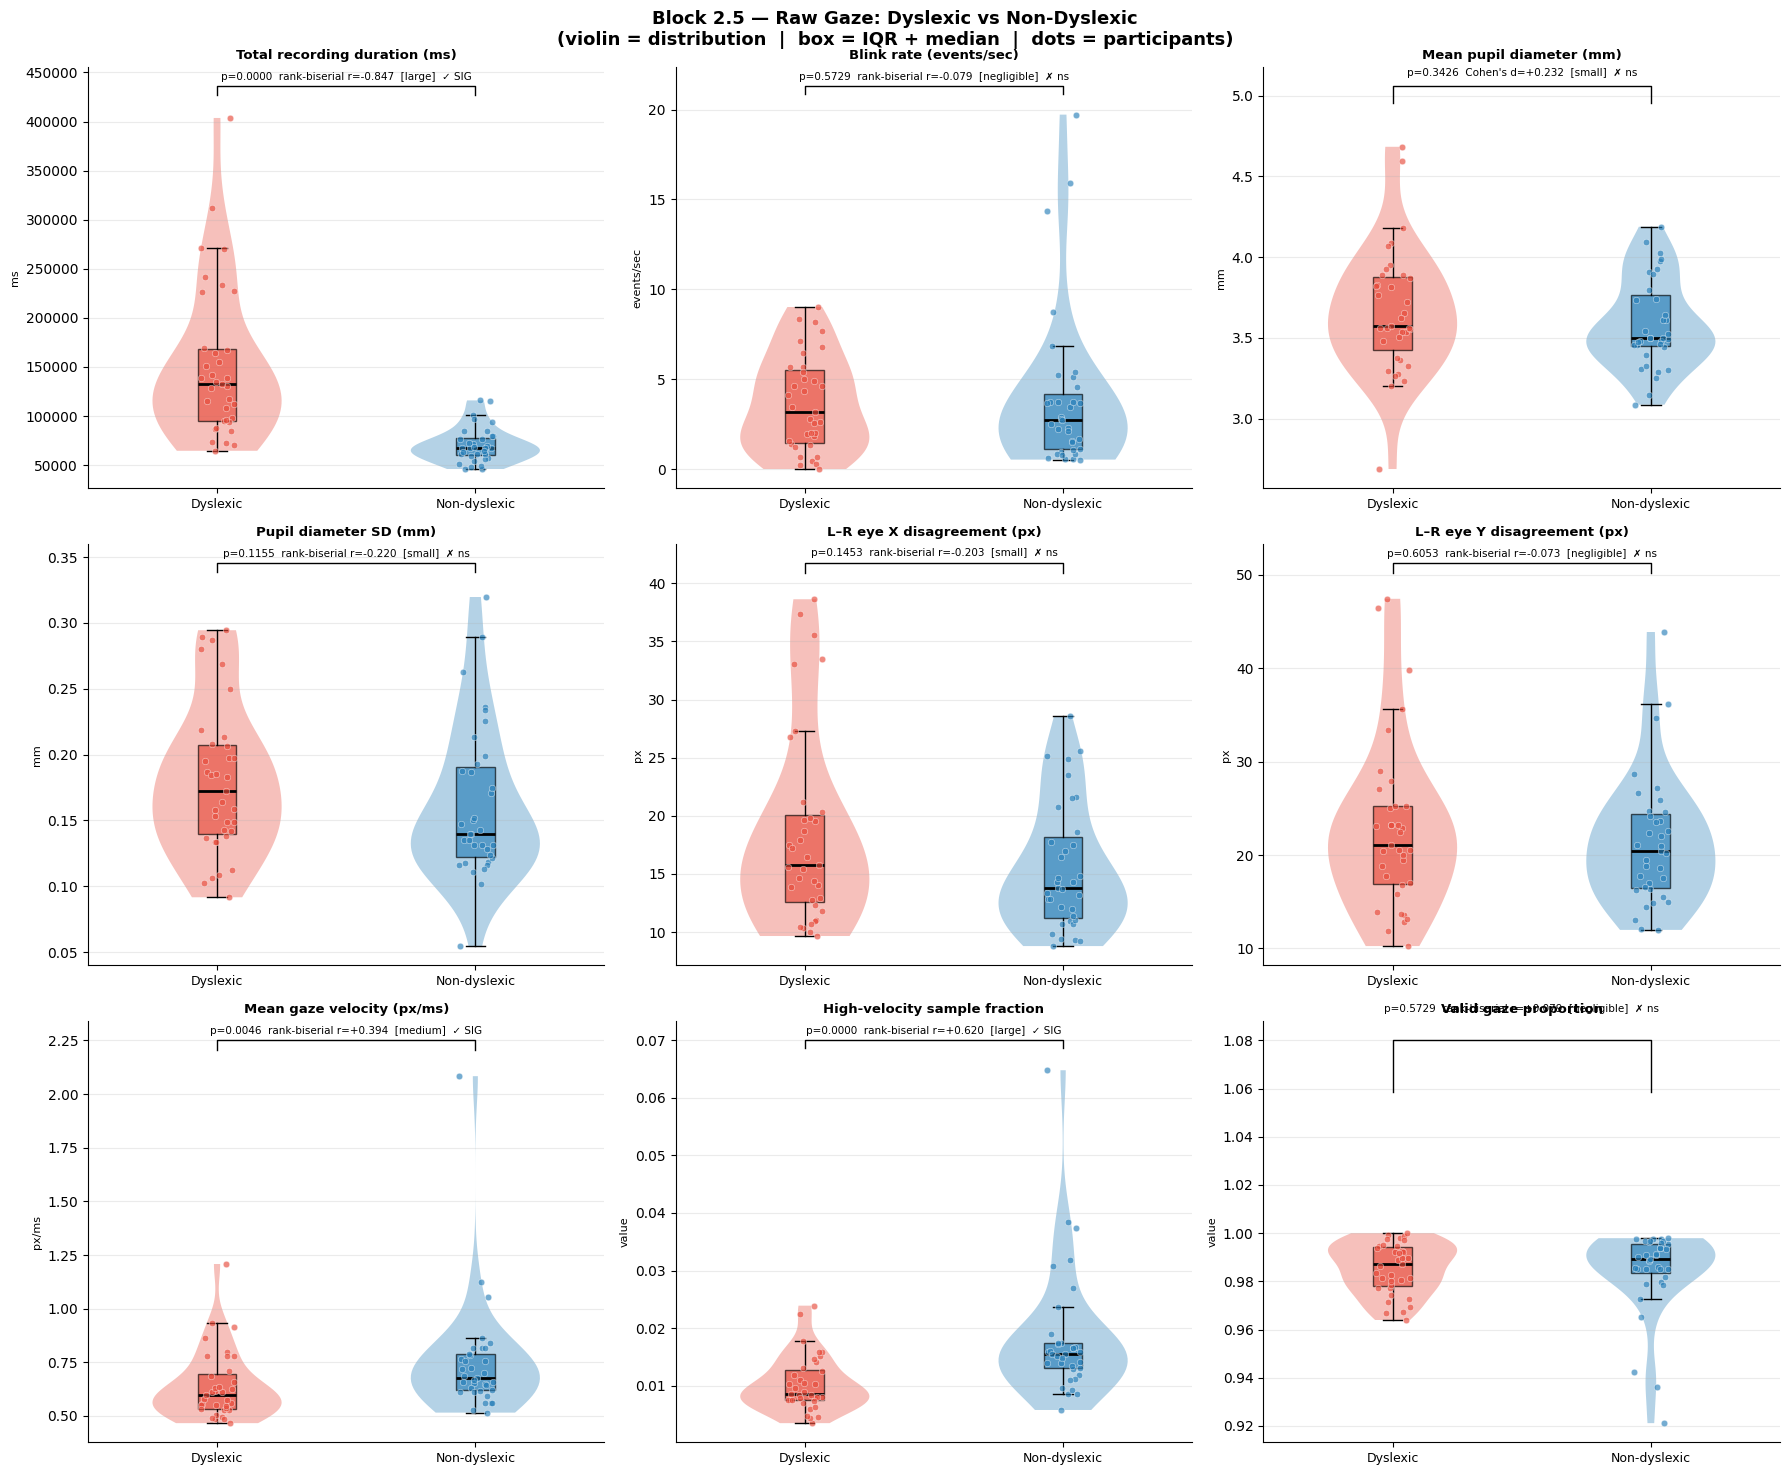

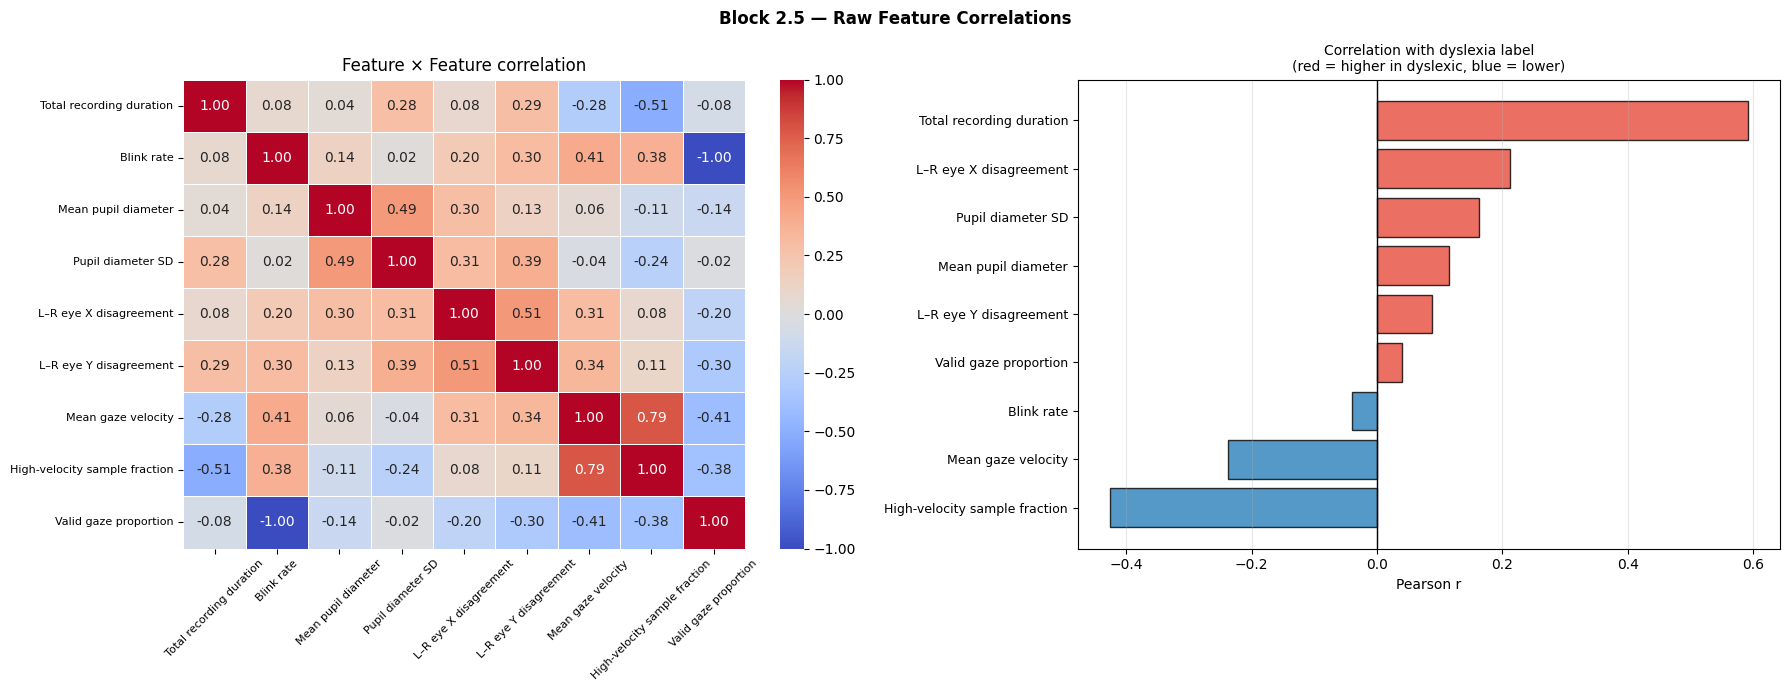


✓ Block 2.5 complete.
  Bonferroni-corrected α = 0.0056
  Significant features   : ['Total recording duration (ms)', 'Mean gaze velocity (px/ms)', 'High-velocity sample fraction']
  Trend features (p<.05) : none
Group column unique values: ['Dyslexic' 'Non-dyslexic']
Group value counts:
 Group
Dyslexic        35
Non-dyslexic    35
Name: count, dtype: int64
groups_ordered lookup: ['Dyslexic', 'Non-dyslexic']


In [14]:
print("--- Block 2.5: Raw Gaze — Statistical Comparison Dyslexic vs Non-Dyslexic ---")
from scipy import stats as sp_stats
import warnings

# ── Helpers ───────────────────────────────────────────────────────────────────
def run_group_test(dys_vals: np.ndarray, ctl_vals: np.ndarray,
                   feature_name: str, alpha_corrected: float = 0.0083):
    """
    Runs Shapiro-Wilk normality check on each group, then selects
    Mann-Whitney U (non-normal) or independent t-test (normal).
    Returns a results dict with all stats needed for the summary table.
    """
    dys_vals = dys_vals[~np.isnan(dys_vals)]
    ctl_vals = ctl_vals[~np.isnan(ctl_vals)]

    # Normality
    _, p_sw_dys = sp_stats.shapiro(dys_vals)
    _, p_sw_ctl = sp_stats.shapiro(ctl_vals)
    both_normal = (p_sw_dys > 0.05) and (p_sw_ctl > 0.05)

    if both_normal:
        stat, p_val = sp_stats.ttest_ind(dys_vals, ctl_vals, equal_var=False)
        pooled_std  = np.sqrt(((len(dys_vals)-1)*dys_vals.std()**2 +
                               (len(ctl_vals)-1)*ctl_vals.std()**2) /
                              (len(dys_vals)+len(ctl_vals)-2))
        effect      = (dys_vals.mean() - ctl_vals.mean()) / (pooled_std + 1e-9)
        effect_name = "Cohen's d"
        test_name   = "Welch t-test"
    else:
        U, p_val    = sp_stats.mannwhitneyu(dys_vals, ctl_vals, alternative='two-sided')
        effect      = 1 - (2 * U) / (len(dys_vals) * len(ctl_vals))
        effect_name = "rank-biserial r"
        test_name   = "Mann-Whitney U"
        stat        = U

    # Effect size magnitude label
    abs_eff = abs(effect)
    if effect_name == "rank-biserial r":
        mag = "negligible" if abs_eff<0.1 else "small" if abs_eff<0.3 else "medium" if abs_eff<0.5 else "large"
    else:
        mag = "negligible" if abs_eff<0.2 else "small" if abs_eff<0.5 else "medium" if abs_eff<0.8 else "large"

    sig = "✓ SIG" if p_val < alpha_corrected else ("~ TREND" if p_val < 0.05 else "✗ ns")

    return {
        "feature"     : feature_name,
        "test"        : test_name,
        "stat"        : stat,
        "p_val"       : p_val,
        "effect"      : effect,
        "effect_name" : effect_name,
        "effect_mag"  : mag,
        "significance": sig,
        # Descriptives
        "dys_mean"    : dys_vals.mean(),
        "dys_median"  : np.median(dys_vals),
        "dys_std"     : dys_vals.std(),
        "dys_iqr"     : np.percentile(dys_vals,75) - np.percentile(dys_vals,25),
        "ctl_mean"    : ctl_vals.mean(),
        "ctl_median"  : np.median(ctl_vals),
        "ctl_std"     : ctl_vals.std(),
        "ctl_iqr"     : np.percentile(ctl_vals,75) - np.percentile(ctl_vals,25),
        "sw_p_dys"    : p_sw_dys,
        "sw_p_ctl"    : p_sw_ctl,
    }


# ── 1. Load all Meaningful_Text raw files and compute participant aggregates ──
raw_files = glob.glob(os.path.join(DATA_PATH, f'Subject_*_{TASK_FILE_GLOB}'))
print(f"Found {len(raw_files)} raw files.")

records = []
for fpath in tqdm(raw_files, desc="Aggregating raw stats"):
    try:
        raw = pd.read_csv(fpath)
        pid = int(os.path.basename(fpath).split('_')[1])
        if pid not in labels_df.index:
            continue

        raw['time_ms'] = (raw['time'] - raw['time'].iloc[0]) / TIME_UNIT_TO_MS
        total_dur_ms   = raw['time_ms'].max()

        # Blink / valid samples
        blink_mask  = (raw['gaze_x_left'] == 0) | (raw['gaze_x_right'] == 0)
        n_total     = len(raw)
        n_valid     = (~blink_mask).sum()
        blink_rate  = blink_mask.sum() / (total_dur_ms / 1000.0)  # blinks/sec

        valid = raw[~blink_mask].copy()

        # Binocular average
        valid['x_avg'] = (valid['gaze_x_left'] + valid['gaze_x_right']) / 2
        valid['y_avg'] = (valid['gaze_y_left'] + valid['gaze_y_right']) / 2

        # L-R eye disagreement (px)
        lr_x_diff = (valid['gaze_x_left'] - valid['gaze_x_right']).abs().mean()
        lr_y_diff = (valid['gaze_y_left'] - valid['gaze_y_right']).abs().mean()

        # Pupil diameter (average of both eyes)
        mean_pupil = ((valid['pupil_left'] + valid['pupil_right']) / 2).mean()
        std_pupil  = ((valid['pupil_left'] + valid['pupil_right']) / 2).std()

        # Gaze velocity (inter-sample displacement in pixels/ms)
        dt_ms  = valid['time_ms'].diff()
        dx_px  = valid['x_avg'].diff()
        dy_px  = valid['y_avg'].diff()
        disp   = np.sqrt(dx_px**2 + dy_px**2)
        vel    = (disp / dt_ms.replace(0, np.nan)).dropna()
        mean_vel        = vel.mean()
        saccade_frac    = (vel > 5.0).mean()   # proportion of time in fast motion (>5 px/ms)

        # Valid gaze proportion
        valid_frac = n_valid / n_total

        records.append({
            'participant_id' : pid,
            'label'          : labels_df.loc[pid, 'dyslexia_label'],
            'label_str'      : labels_df.loc[pid, 'dyslexia_label_str'],
            'total_dur_ms'   : total_dur_ms,
            'valid_frac'     : valid_frac,
            'blink_rate'     : blink_rate,
            'mean_pupil'     : mean_pupil,
            'std_pupil'      : std_pupil,
            'lr_x_diff_px'   : lr_x_diff,
            'lr_y_diff_px'   : lr_y_diff,
            'mean_velocity'  : mean_vel,
            'saccade_frac'   : saccade_frac,
        })
    except Exception as e:
        warnings.warn(f"Failed on {fpath}: {e}")

raw_agg_df = pd.DataFrame(records)
dys_df = raw_agg_df[raw_agg_df['label'] == 1]
ctl_df = raw_agg_df[raw_agg_df['label'] == 0]
print(f"\nParticipants loaded — Dyslexic: {len(dys_df)}  Non-dyslexic: {len(ctl_df)}")

# ── 2. Statistical tests ───────────────────────────────────────────────────────
RAW_FEATURES = [
    ('total_dur_ms',   'Total recording duration (ms)'),
    ('blink_rate',     'Blink rate (events/sec)'),
    ('mean_pupil',     'Mean pupil diameter (mm)'),
    ('std_pupil',      'Pupil diameter SD (mm)'),
    ('lr_x_diff_px',   'L–R eye X disagreement (px)'),
    ('lr_y_diff_px',   'L–R eye Y disagreement (px)'),
    ('mean_velocity',  'Mean gaze velocity (px/ms)'),
    ('saccade_frac',   'High-velocity sample fraction'),
    ('valid_frac',     'Valid gaze proportion'),
]
N_RAW_FEATURES  = len(RAW_FEATURES)
ALPHA_CORRECTED = 0.05 / N_RAW_FEATURES

test_results = []
for col, label in RAW_FEATURES:
    res = run_group_test(dys_df[col].values, ctl_df[col].values,
                         label, ALPHA_CORRECTED)
    test_results.append(res)

# ── 3. Print summary table ─────────────────────────────────────────────────────
print(f"\n{'='*95}")
print(f"  Statistical Summary — Raw Gaze Features  "
      f"(Bonferroni α = 0.05/{N_RAW_FEATURES} = {ALPHA_CORRECTED:.4f})")
print(f"{'='*95}")
print(f"  {'Feature':<38} {'Test':<18} {'p-val':>8} {'Effect':>8} {'Mag':<12} {'Sig'}")
print(f"  {'-'*88}")
for r in test_results:
    print(f"  {r['feature']:<38} {r['test']:<18} {r['p_val']:>8.4f} "
          f"{r['effect']:>+8.3f}  {r['effect_mag']:<12} {r['significance']}")

print(f"\n  Effect sign convention: positive = Dyslexic > Non-dyslexic")
print(f"\n  Descriptive stats (Dyslexic  |  Non-dyslexic):")
print(f"  {'Feature':<38} {'Dys mean':>10} {'Dys med':>10} {'Dys IQR':>10}"
      f" {'Ctl mean':>10} {'Ctl med':>10} {'Ctl IQR':>10}")
print(f"  {'-'*88}")
for r in test_results:
    print(f"  {r['feature']:<38} {r['dys_mean']:>10.3f} {r['dys_median']:>10.3f} "
          f"{r['dys_iqr']:>10.3f} {r['ctl_mean']:>10.3f} {r['ctl_median']:>10.3f} "
          f"{r['ctl_iqr']:>10.3f}")

# ── 4. Visualisations ─────────────────────────────────────────────────────────
PALETTE = {'Dyslexic': '#E74C3C', 'Non-dyslexic': '#2980B9'}
raw_agg_df['Group'] = raw_agg_df['label_str'].map(
    {'dyslexic': 'Dyslexic', 'non-dyslexic': 'Non-dyslexic'}
)

n_cols = 3
n_rows = int(np.ceil(N_RAW_FEATURES / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()
fig.suptitle('Block 2.5 — Raw Gaze: Dyslexic vs Non-Dyslexic\n'
             '(violin = distribution  |  box = IQR + median  |  dots = participants)',
             fontsize=13, fontweight='bold')

for ax_idx, (col, feat_label) in enumerate(RAW_FEATURES):
    ax  = axes[ax_idx]
    res = test_results[ax_idx]

    # Violin
    groups_ordered = ['Dyslexic', 'Non-dyslexic']
    data_grouped = [raw_agg_df[raw_agg_df['Group'] == g][col].dropna().values
                        for g in groups_ordered]
    
    # Guard: skip violin if either group is empty or constant (all same value)
    if any(len(d) < 2 or d.std() == 0 for d in data_grouped):
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                transform=ax.transAxes, color='gray')
        ax.set_title(feat_label, fontsize=9.5, fontweight='bold')
        continue


    parts = ax.violinplot(data_grouped, positions=[0, 1],
                           showmedians=False, showextrema=False)
    for pc, color in zip(parts['bodies'], list(PALETTE.values())):
        pc.set_facecolor(color)
        pc.set_alpha(0.35)

    # Box
    bp = ax.boxplot(data_grouped, positions=[0, 1], widths=0.15,
                     patch_artist=True, showfliers=False,
                     medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], list(PALETTE.values())):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    # Strip (individual participants)
    for grp_idx, (grp_name, color) in enumerate(PALETTE.items()):
        vals = raw_agg_df[raw_agg_df['Group'] == grp_name][col].dropna().values
        jitter = np.random.default_rng(42).uniform(-0.07, 0.07, len(vals))
        ax.scatter(np.full(len(vals), grp_idx) + jitter, vals,
                   color=color, alpha=0.65, s=22, zorder=4, edgecolors='white',
                   linewidths=0.4)

    # Significance annotation
    y_max  = max(np.nanmax(raw_agg_df[col]), 1e-9)
    y_top  = y_max * 1.08
    sig_text = (f"p={res['p_val']:.4f}  {res['effect_name']}={res['effect']:+.3f}"
                f"  [{res['effect_mag']}]  {res['significance']}")
    ax.plot([0, 0, 1, 1], [y_top*0.98, y_top, y_top, y_top*0.98],
            color='black', lw=1)
    ax.text(0.5, y_top * 1.01, sig_text, ha='center', va='bottom',
            fontsize=7.5, color='black')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Dyslexic', 'Non-dyslexic'], fontsize=9)
    ax.set_title(feat_label, fontsize=9.5, fontweight='bold')
    ax.set_ylabel(feat_label.split('(')[-1].rstrip(')') if '(' in feat_label else 'value',
                  fontsize=8)
    ax.grid(True, alpha=0.25, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused axes
for ax in axes[N_RAW_FEATURES:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'block2_5_raw_group_comparison.png'), dpi=150)
plt.show()

# ── 5. Correlation heatmap of raw features ────────────────────────────────────
feat_cols_only = [c for c, _ in RAW_FEATURES]
corr_full = raw_agg_df[feat_cols_only + ['label']].corr()

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))
fig2.suptitle('Block 2.5 — Raw Feature Correlations', fontsize=12, fontweight='bold')

short_labels = [l.split('(')[0].strip() for _, l in RAW_FEATURES]
sns.heatmap(corr_full.loc[feat_cols_only, feat_cols_only],
            ax=axes2[0], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, vmin=-1, vmax=1,
            xticklabels=short_labels, yticklabels=short_labels)
axes2[0].set_title('Feature × Feature correlation')
axes2[0].tick_params(axis='x', rotation=45, labelsize=8)
axes2[0].tick_params(axis='y', labelsize=8)

# Feature × label correlation bar
label_corr = corr_full.loc[feat_cols_only, 'label'].sort_values()
colors_bar = ['#E74C3C' if v > 0 else '#2980B9' for v in label_corr]
axes2[1].barh(range(len(label_corr)), label_corr.values, color=colors_bar,
               edgecolor='black', alpha=0.8)
axes2[1].set_yticks(range(len(label_corr)))
axes2[1].set_yticklabels([short_labels[feat_cols_only.index(i)]
                           for i in label_corr.index], fontsize=9)
axes2[1].axvline(0, color='black', lw=1)
axes2[1].set_title('Correlation with dyslexia label\n(red = higher in dyslexic, blue = lower)',
                    fontsize=10)
axes2[1].set_xlabel('Pearson r')
axes2[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'block2_5_raw_correlations.png'), dpi=150)
plt.show()

print(f"\n✓ Block 2.5 complete.")
print(f"  Bonferroni-corrected α = {ALPHA_CORRECTED:.4f}")
sig_features = [r['feature'] for r in test_results if '✓' in r['significance']]
trend_features = [r['feature'] for r in test_results if 'TREND' in r['significance']]
print(f"  Significant features   : {sig_features if sig_features else 'none'}")
print(f"  Trend features (p<.05) : {trend_features if trend_features else 'none'}")
print("Group column unique values:", raw_agg_df['Group'].unique())
print("Group value counts:\n", raw_agg_df['Group'].value_counts())
print("groups_ordered lookup:", groups_ordered)


BLOCK 3 — Load Phase-1 artefacts

---

In [15]:
print("--- Block 3: Loading Phase-1 Artefacts ---")

with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)
print(f"Scaler loaded from {SCALER_PATH}")
print(f"  means : {np.round(scaler.mean_, 3)}")
print(f"  scales: {np.round(scaler.scale_, 3)}")

# We load the encoder later after we know max_len (needed for model building)
# Just verify the file exists now
assert os.path.exists(ENCODER_PATH), f"Encoder not found at {ENCODER_PATH}"
print(f"Encoder path verified: {ENCODER_PATH}")

--- Block 3: Loading Phase-1 Artefacts ---
Scaler loaded from /kaggle/input/models/muhammedomran/scalar/tensorflow2/default/1/scaler_v3.pkl
  means : [1.96775e+02 7.27000e-01 5.26000e-01 3.00000e-03 3.25000e-01 1.15730e+01]
  scales: [8.1833e+01 3.0400e-01 2.3700e-01 3.0000e-03 4.6800e-01 1.1880e+00]
Encoder path verified: /kaggle/input/models/muhammedomran/gaze-encoder-v3/tensorflow2/default/1/gaze_encoder_v3.keras


In [16]:
print("--- Block 4: I-DT Fixation Detection (from raw binocular gaze files) ---")

# ── Raw file column schema (confirmed from Subject_1113_T4_Meaningful_Text_raw.csv) ──
# time          : int64  microseconds since tracker start
# gaze_x_left   : float64  left eye X in pixels
# gaze_y_left   : float64  left eye Y in pixels
# gaze_x_right  : float64  right eye X in pixels
# gaze_y_right  : float64  right eye Y in pixels
# pupil_left    : float64  left pupil diameter (0.0 = blink / lost tracking)
# pupil_right   : float64  right pupil diameter
# stimfile      : str      stimulus image filename
# subject_id    : int64

def load_and_clean_raw(filepath: str) -> pd.DataFrame:
    """
    Load a raw ETDD70 gaze file and return a clean DataFrame with columns:
        time_ms   : elapsed time in milliseconds (0-based)
        x_norm    : binocular-average X normalised to [0, 1]
        y_norm    : binocular-average Y normalised to [0, 1]

    Blink removal: any sample where gaze_x_left OR gaze_x_right == 0.0
    is discarded (pupil loss encodes as 0 in this dataset).
    Binocular average: simple mean of left + right eye when both valid.
    """
    raw = pd.read_csv(filepath)

    # Convert microseconds → milliseconds, zero-based
    raw['time_ms'] = (raw['time'] - raw['time'].iloc[0]) / TIME_UNIT_TO_MS

    # Remove blinks / lost-tracking samples (either eye at 0)
    valid = (raw['gaze_x_left'] > 0) & (raw['gaze_x_right'] > 0)
    raw = raw[valid].reset_index(drop=True)

    # Binocular average
    raw['x_avg'] = (raw['gaze_x_left'] + raw['gaze_x_right']) / 2.0
    raw['y_avg'] = (raw['gaze_y_left'] + raw['gaze_y_right']) / 2.0

    # Normalise to [0, 1]
    raw['x_norm'] = raw['x_avg'] / SCREEN_W
    raw['y_norm'] = raw['y_avg'] / SCREEN_H

    return raw[['time_ms', 'x_norm', 'y_norm']].copy()


def detect_fixations_idt(gaze_df: pd.DataFrame,
                          dispersion_threshold: float = DISPERSION_THRESHOLD,
                          min_duration_ms: float = DURATION_THRESHOLD_MS,
                          max_duration_ms: float = 1500.0) -> pd.DataFrame:
    """
    I-DT fixation detection on cleaned, normalised gaze samples.
    Uses the SAME threshold (0.041) as the OneStop foundation model
    and the WebQAmGaze webcam pipeline — ensuring fixation identity
    is consistent across all three datasets.

    Input : gaze_df with columns [time_ms, x_norm, y_norm]
    Output: DataFrame [duration_ms, fix_x_norm, fix_y_norm, onset_ms]
    """
    xs = gaze_df['x_norm'].values
    ys = gaze_df['y_norm'].values
    ts = gaze_df['time_ms'].values
    n  = len(xs)

    if n < 2:
        return pd.DataFrame(columns=['duration_ms', 'fix_x_norm',
                                     'fix_y_norm', 'onset_ms'])

    fixations = []
    i = 0
    while i < n:
        j = i + 1
        while j < n:
            disp = ((xs[i:j+1].max() - xs[i:j+1].min()) +
                    (ys[i:j+1].max() - ys[i:j+1].min()))
            if disp > dispersion_threshold:
                break
            j += 1
        dur = ts[j-1] - ts[i]
        if min_duration_ms <= dur <= max_duration_ms:
            fixations.append({
                'duration_ms': float(dur),
                'fix_x_norm':  float(np.mean(xs[i:j])),
                'fix_y_norm':  float(np.mean(ys[i:j])),
                'onset_ms':    float(ts[i]),
            })
        i = j

    return pd.DataFrame(fixations)


print("I-DT pipeline ready.")
print(f"  Dispersion threshold : {DISPERSION_THRESHOLD} norm units")
print(f"  Min fixation duration: {DURATION_THRESHOLD_MS} ms")
print(f"  Max fixation duration: 1500 ms")
print(f"  Blink removal        : discard sample if either eye gaze == 0")
print(f"  Binocular averaging  : (left + right) / 2 when both valid")

--- Block 4: I-DT Fixation Detection (from raw binocular gaze files) ---
I-DT pipeline ready.
  Dispersion threshold : 0.041 norm units
  Min fixation duration: 100 ms
  Max fixation duration: 1500 ms
  Blink removal        : discard sample if either eye gaze == 0
  Binocular averaging  : (left + right) / 2 when both valid


--- Block 4.5: Raw File Investigation ---
Inspecting: Subject_1003_T4_Meaningful_Text_raw.csv

── Column inventory ──
  Shape: (15332, 9)
  time                 dtype=int64       zeros=0  NaN=0
  gaze_x_left          dtype=float64     zeros=31  NaN=0
  gaze_y_left          dtype=float64     zeros=31  NaN=0
  gaze_x_right         dtype=float64     zeros=33  NaN=0
  gaze_y_right         dtype=float64     zeros=33  NaN=0
  pupil_left           dtype=float64     zeros=31  NaN=0
  pupil_right          dtype=float64     zeros=33  NaN=0
  stimfile             dtype=object      zeros=N/A  NaN=0
  subject_id           dtype=int64       zeros=0  NaN=0

── Sampling rate ──
  Median Δt: 4.0 ms  → ~250 Hz
  Total recording duration: 61319 ms (61.3 s)
  Total samples: 15,332

── Blink / missing data ──
  Left eye missing  :    31 (0.20%)
  Right eye missing :    33 (0.22%)
  Both missing      :    29 (0.19%)
  Either missing    :    35 (0.23%)
  → Discarding 'either missing' retains 15,297 / 15,332 

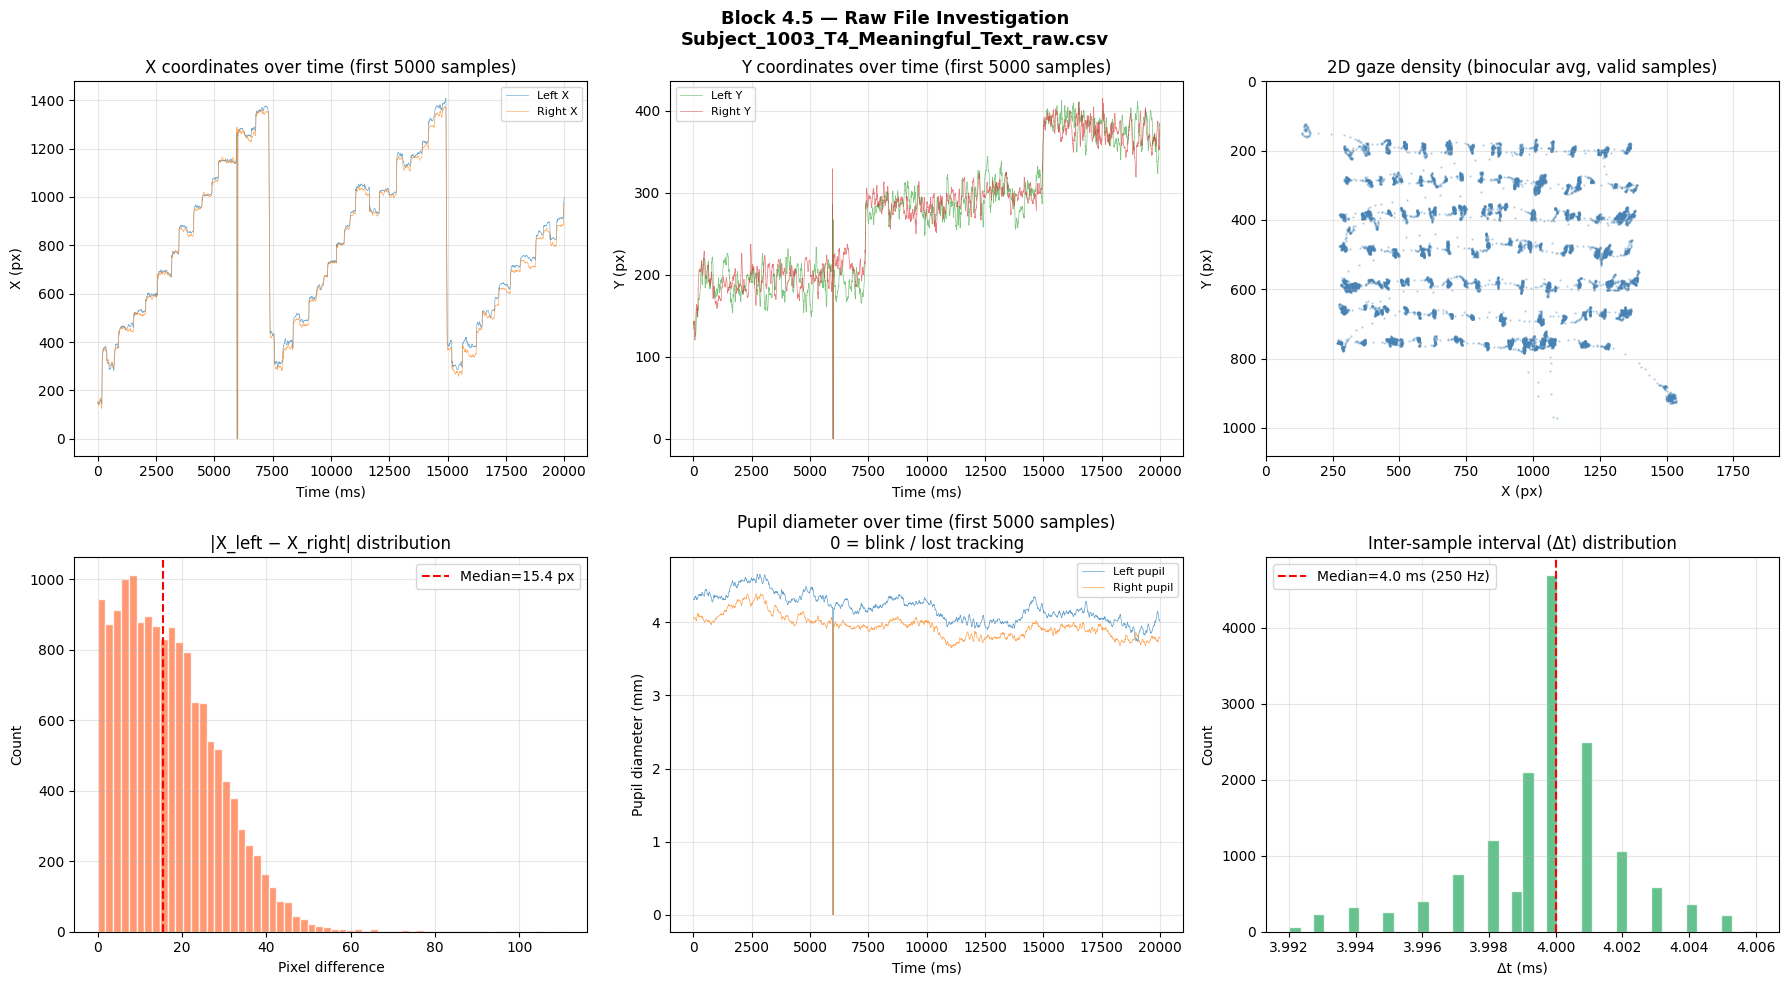


Summary for pipeline design:
  ✓ time column is microseconds  → divide by 1000.0 for ms
  ✓ Screen: 1920×1080 px confirmed
  ✓ Blink encoding: x==0 for both eyes, or either eye
  ✓ Binocular average is appropriate (median disagreement 15 px)
  ✓ Sampling rate ~250 Hz → I-DT min window = 100ms = ~25 samples


In [17]:
print("--- Block 4.5: Raw File Investigation ---")
import matplotlib.pyplot as plt

# ── Find one representative file to inspect ───────────────────────────────────
sample_files = glob.glob(os.path.join(DATA_PATH, f'Subject_*_{TASK_FILE_GLOB}'))
if not sample_files:
    print("ERROR: No raw files found. Check DATA_PATH and TASK_FILE_GLOB.")
else:
    sample_path = sorted(sample_files)[0]
    print(f"Inspecting: {os.path.basename(sample_path)}")
    raw_sample = pd.read_csv(sample_path)

    print(f"\n── Column inventory ──")
    print(f"  Shape: {raw_sample.shape}")
    for col in raw_sample.columns:
        dtype = raw_sample[col].dtype
        n_zero = (raw_sample[col] == 0).sum() if dtype != object else 'N/A'
        n_nan  = raw_sample[col].isna().sum()
        print(f"  {col:20s} dtype={str(dtype):10s}  zeros={n_zero}  NaN={n_nan}")

    # ── Sampling rate ─────────────────────────────────────────────────────────
    raw_sample['time_ms'] = (raw_sample['time'] - raw_sample['time'].iloc[0]) / TIME_UNIT_TO_MS
    dt = raw_sample['time_ms'].diff().dropna()
    hz_estimate = round(1000.0 / dt.median())
    print(f"\n── Sampling rate ──")
    print(f"  Median Δt: {dt.median():.1f} ms  → ~{hz_estimate} Hz")
    print(f"  Total recording duration: {raw_sample['time_ms'].max():.0f} ms "
          f"({raw_sample['time_ms'].max()/1000:.1f} s)")
    print(f"  Total samples: {len(raw_sample):,}")

    # ── Blink analysis ────────────────────────────────────────────────────────
    blink_left   = (raw_sample['gaze_x_left']  == 0)
    blink_right  = (raw_sample['gaze_x_right'] == 0)
    blink_both   = blink_left & blink_right
    blink_either = blink_left | blink_right
    print(f"\n── Blink / missing data ──")
    print(f"  Left eye missing  : {blink_left.sum():5d} ({blink_left.mean()*100:.2f}%)")
    print(f"  Right eye missing : {blink_right.sum():5d} ({blink_right.mean()*100:.2f}%)")
    print(f"  Both missing      : {blink_both.sum():5d} ({blink_both.mean()*100:.2f}%)")
    print(f"  Either missing    : {blink_either.sum():5d} ({blink_either.mean()*100:.2f}%)")
    print(f"  → Discarding 'either missing' retains "
          f"{(~blink_either).sum():,} / {len(raw_sample):,} samples")

    # ── Gaze coordinate ranges ────────────────────────────────────────────────
    valid = ~blink_either
    print(f"\n── Gaze coordinate ranges (valid samples only) ──")
    for col in ['gaze_x_left','gaze_y_left','gaze_x_right','gaze_y_right']:
        s = raw_sample.loc[valid, col]
        print(f"  {col:20s}: min={s.min():.1f}  max={s.max():.1f}  mean={s.mean():.1f}")

    # ── Left vs Right eye agreement ───────────────────────────────────────────
    valid_df = raw_sample[valid].copy()
    x_diff = (valid_df['gaze_x_left'] - valid_df['gaze_x_right']).abs()
    y_diff = (valid_df['gaze_y_left'] - valid_df['gaze_y_right']).abs()
    print(f"\n── Left–Right eye disagreement (valid samples) ──")
    print(f"  |X_left - X_right| : mean={x_diff.mean():.1f} px  "
          f"median={x_diff.median():.1f} px  p95={x_diff.quantile(0.95):.1f} px")
    print(f"  |Y_left - Y_right| : mean={y_diff.mean():.1f} px  "
          f"median={y_diff.median():.1f} px  p95={y_diff.quantile(0.95):.1f} px")
    print(f"  → Binocular average reduces effective noise by ~√2")

    # ── Visualisations ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Block 4.5 — Raw File Investigation\n{os.path.basename(sample_path)}',
                 fontsize=13, fontweight='bold')

    # 1. X over time (first 5000 samples)
    axes[0,0].plot(raw_sample['time_ms'].iloc[:5000],
                   raw_sample['gaze_x_left'].iloc[:5000],
                   alpha=0.6, lw=0.5, label='Left X')
    axes[0,0].plot(raw_sample['time_ms'].iloc[:5000],
                   raw_sample['gaze_x_right'].iloc[:5000],
                   alpha=0.6, lw=0.5, label='Right X')
    axes[0,0].set_title('X coordinates over time (first 5000 samples)')
    axes[0,0].set_xlabel('Time (ms)')
    axes[0,0].set_ylabel('X (px)')
    axes[0,0].legend(fontsize=8)
    axes[0,0].grid(True, alpha=0.3)

    # 2. Y over time
    axes[0,1].plot(raw_sample['time_ms'].iloc[:5000],
                   raw_sample['gaze_y_left'].iloc[:5000],
                   alpha=0.6, lw=0.5, label='Left Y', color='C2')
    axes[0,1].plot(raw_sample['time_ms'].iloc[:5000],
                   raw_sample['gaze_y_right'].iloc[:5000],
                   alpha=0.6, lw=0.5, label='Right Y', color='C3')
    axes[0,1].set_title('Y coordinates over time (first 5000 samples)')
    axes[0,1].set_xlabel('Time (ms)')
    axes[0,1].set_ylabel('Y (px)')
    axes[0,1].legend(fontsize=8)
    axes[0,1].grid(True, alpha=0.3)

    # 3. 2D scanpath (binocular average, valid only)
    valid_df['x_avg'] = (valid_df['gaze_x_left'] + valid_df['gaze_x_right']) / 2
    valid_df['y_avg'] = (valid_df['gaze_y_left'] + valid_df['gaze_y_right']) / 2
    axes[0,2].scatter(valid_df['x_avg'], valid_df['y_avg'],
                      s=0.5, alpha=0.3, c='steelblue')
    axes[0,2].set_title('2D gaze density (binocular avg, valid samples)')
    axes[0,2].set_xlabel('X (px)')
    axes[0,2].set_ylabel('Y (px)')
    axes[0,2].invert_yaxis()
    axes[0,2].set_xlim(0, SCREEN_W)
    axes[0,2].set_ylim(SCREEN_H, 0)
    axes[0,2].grid(True, alpha=0.3)

    # 4. Left-Right X disagreement distribution
    axes[1,0].hist(x_diff, bins=60, color='coral', edgecolor='white', alpha=0.8)
    axes[1,0].axvline(x_diff.median(), color='red', linestyle='--',
                      label=f'Median={x_diff.median():.1f} px')
    axes[1,0].set_title('|X_left − X_right| distribution')
    axes[1,0].set_xlabel('Pixel difference')
    axes[1,0].set_ylabel('Count')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # 5. Pupil diameter over time
    axes[1,1].plot(raw_sample['time_ms'].iloc[:5000],
                   raw_sample['pupil_left'].iloc[:5000],
                   alpha=0.7, lw=0.5, label='Left pupil')
    axes[1,1].plot(raw_sample['time_ms'].iloc[:5000],
                   raw_sample['pupil_right'].iloc[:5000],
                   alpha=0.7, lw=0.5, label='Right pupil')
    axes[1,1].set_title('Pupil diameter over time (first 5000 samples)\n'
                        '0 = blink / lost tracking')
    axes[1,1].set_xlabel('Time (ms)')
    axes[1,1].set_ylabel('Pupil diameter (mm)')
    axes[1,1].legend(fontsize=8)
    axes[1,1].grid(True, alpha=0.3)

    # 6. Δt histogram (sampling regularity)
    axes[1,2].hist(dt.clip(0, 20), bins=40, color='mediumseagreen',
                   edgecolor='white', alpha=0.8)
    axes[1,2].axvline(dt.median(), color='red', linestyle='--',
                      label=f'Median={dt.median():.1f} ms ({hz_estimate} Hz)')
    axes[1,2].set_title('Inter-sample interval (Δt) distribution')
    axes[1,2].set_xlabel('Δt (ms)')
    axes[1,2].set_ylabel('Count')
    axes[1,2].legend()
    axes[1,2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'block4_5_raw_investigation.png'), dpi=150)
    plt.show()

    print(f"\nSummary for pipeline design:")
    print(f"  ✓ time column is microseconds  → divide by {TIME_UNIT_TO_MS} for ms")
    print(f"  ✓ Screen: {SCREEN_W:.0f}×{SCREEN_H:.0f} px confirmed")
    print(f"  ✓ Blink encoding: x==0 for both eyes, or either eye")
    print(f"  ✓ Binocular average is appropriate (median disagreement "
          f"{x_diff.median():.0f} px)")
    print(f"  ✓ Sampling rate ~{hz_estimate} Hz → I-DT min window = "
          f"{DURATION_THRESHOLD_MS}ms = ~{int(DURATION_THRESHOLD_MS/(1000/hz_estimate))} samples")

BLOCK 5 — Per-participant preprocessing pipeline

---
ETDD70 stores fixation + saccade CSVs per participant per task.
We process the RAW fixation files, apply the same chain as Phase 1:
clean → normalise → Y-snap → I-DT filter → feature engineering → sequencing

---
Tasks used: Meaningful_Text, Pseudo_Text   (Syllables dropped — no webcam equiv)

---

In [18]:
print("--- Block 5: Per-participant preprocessing pipeline ---")

def process_participant_task(participant_id: int,
                             scaler: 'StandardScaler') -> np.ndarray:
    """
    Full preprocessing for one participant, Meaningful_Text task only.
    v2: Blink-crossing artifact masking via inter-fixation time gaps.
    """
    # ── 1. Find raw file ──
    pattern = os.path.join(DATA_PATH, f'Subject_{participant_id}_{TASK_FILE_GLOB}')
    files = glob.glob(pattern)
    if not files:
        return np.array([])

    # ── 2–4. Load, clean blinks, binocular avg, normalise ──
    try:
        gaze_df = load_and_clean_raw(files[0])
    except Exception as e:
        warnings.warn(f"PID {participant_id}: failed to load raw file — {e}")
        return np.array([])
    if len(gaze_df) < 2:
        return np.array([])

    # ── 5. I-DT fixation detection ──
    fix_df = detect_fixations_idt(gaze_df)
    if len(fix_df) < SEQUENCE_LENGTH:
        return np.array([])
    fix_df = fix_df.reset_index(drop=True)

    # ── 6. Feature engineering ──
    fix_df['feat_duration'] = fix_df['duration_ms'].astype(float)
    fix_df['feat_x'] = fix_df['fix_x_norm'].astype(float)
    fix_df['feat_y'] = fix_df['fix_y_norm'].astype(float)

    # Saccade amplitude: Euclidean distance between consecutive centroids
    dx = fix_df['feat_x'].diff().fillna(0.0)
    dy = fix_df['feat_y'].diff().fillna(0.0)
    fix_df['feat_amplitude'] = np.sqrt(dx**2 + dy**2)
    fix_df.loc[0, 'feat_amplitude'] = 0.0

    # ── NEW: Mask blink-crossing artifacts ──
    # Compute inter-fixation time gap (onset_i - end_{i-1})
    prev_end = fix_df['onset_ms'].shift(1) + fix_df['duration_ms'].shift(1)
    time_gap = fix_df['onset_ms'] - prev_end  # NaN for first fixation

    # Any amplitude crossing a blink gap → set to 0 (no saccade info)
    blink_cross_mask = time_gap > GAP_THRESHOLD_MS
    n_masked = blink_cross_mask.sum()
    fix_df.loc[blink_cross_mask.values, 'feat_amplitude'] = 0.0

    # ── ALSO: Cap at physiological max as safety net ──
    # This catches any artifacts that slip through (e.g., very short blinks)
    n_capped = (fix_df['feat_amplitude'] > AMPLITUDE_MAX).sum()
    fix_df['feat_amplitude'] = fix_df['feat_amplitude'].clip(upper=AMPLITUDE_MAX)

    if n_masked > 0 or n_capped > 0:
        pass  # silent — uncomment below for debugging
        print(f"  PID {participant_id}: masked {n_masked} blink-cross, capped {n_capped} amp")

    # IS_REGRESSION — purely from X: current_x < previous_x
    prev_x = fix_df['feat_x'].shift(1)
    fix_df['feat_regression'] = (
        (fix_df['feat_x'] < prev_x) & prev_x.notna()
    ).astype(int)

    # ── FIX: Don't compute efficiency for masked amplitudes ──
    is_first = prev_x.isna()
    safe_amp = np.maximum(fix_df['feat_amplitude'].values, AMPLITUDE_FLOOR)
    raw_log = np.log1p(fix_df['feat_duration'].values / safe_amp)
    # Masked amplitudes (==0) get efficiency = 0, same as first fixation
    fix_df['feat_efficiency'] = np.where(
        is_first.values | blink_cross_mask.values,  # ← ALSO mask efficiency for blink crossings
        0.0,
        np.clip(raw_log, 0.0, EFFICIENCY_CAP)
    )

    # ── 7. Scale ──
    features_raw = fix_df[FEATURE_COLS].values.astype(np.float32)
    features_scaled = scaler.transform(features_raw).astype(np.float32)

    # ── 8. Sliding-window sequences ──
    seqs = []
    n = len(features_scaled)
    for i in range(0, n - SEQUENCE_LENGTH + 1, STEP):
        seqs.append(features_scaled[i : i + SEQUENCE_LENGTH])
    if not seqs:
        return np.array([])
    return np.array(seqs, dtype=np.float32)
      


print("Preprocessing function defined.")
print(f"  File pattern : Subject_{{pid}}_{TASK_FILE_GLOB}")
print(f"  Features     : {FEATURE_COLS}")

--- Block 5: Per-participant preprocessing pipeline ---
Preprocessing function defined.
  File pattern : Subject_{pid}_*_Meaningful_Text_raw.csv
  Features     : ['feat_duration', 'feat_x', 'feat_y', 'feat_amplitude', 'feat_regression', 'feat_efficiency']


--- Block 5.5: I-DT Output Investigation (one participant) ---
Processing participant: 1003

── Raw gaze after blink removal ──
  Samples : 15,297
  Duration: 61319 ms
           x_norm      y_norm
count  15297.0000  15297.0000
mean       0.4442      0.4623
std        0.1825      0.1785
min        0.0705      0.1151
25%        0.2711      0.3333
50%        0.4660      0.4557
75%        0.5988      0.6193
max        0.7991      0.8996

── I-DT fixations detected: 207 ──
       duration_ms  fix_x_norm  fix_y_norm   onset_ms
count      207.000     207.000     207.000    207.000
mean       269.349       0.455       0.453  29628.929
std        122.615       0.181       0.179  17630.503
min        103.875       0.079       0.127      0.000
25%        174.002       0.297       0.284  13756.808
50%        247.972       0.487       0.455  29969.403
75%        327.935       0.606       0.615  44192.042
max        643.926       0.792       0.847  61098.688

── Feature stats (pre-scaling) ──
     

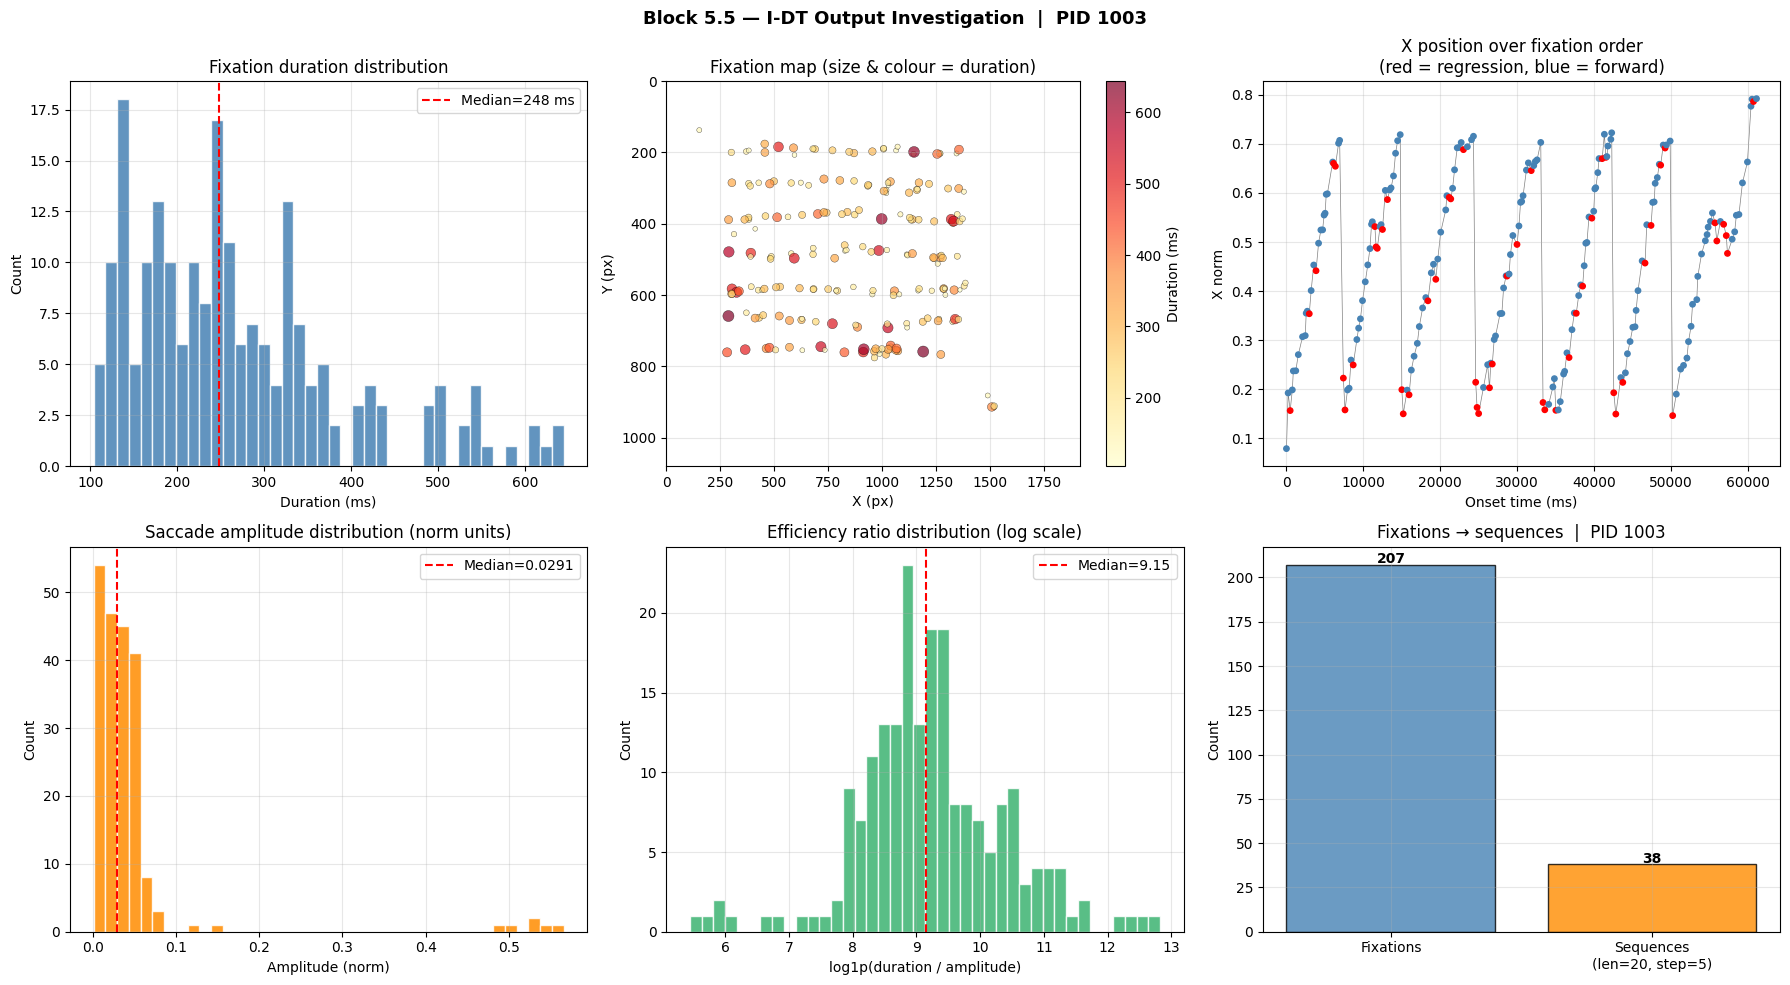


✓ Block 5.5 complete.
  This participant contributes 38 sequences of shape (20, 6).
  Fixation coverage confirms I-DT is working correctly on ETDD70 raw data.


In [19]:
print("--- Block 5.5: I-DT Output Investigation (one participant) ---")

# Run the full pipeline on the first available participant
sample_files = glob.glob(os.path.join(DATA_PATH, f'Subject_*_{TASK_FILE_GLOB}'))
if not sample_files:
    print("No files found — check DATA_PATH.")
else:
    sample_path = sorted(sample_files)[0]
    sample_pid  = int(os.path.basename(sample_path).split('_')[1])
    print(f"Processing participant: {sample_pid}")

    # Run loader + I-DT directly so we can inspect intermediate outputs
    gaze_df_sample = load_and_clean_raw(sample_path)
    fix_df_sample  = detect_fixations_idt(gaze_df_sample)

    print(f"\n── Raw gaze after blink removal ──")
    print(f"  Samples : {len(gaze_df_sample):,}")
    print(f"  Duration: {gaze_df_sample['time_ms'].max():.0f} ms")
    print(gaze_df_sample[['x_norm', 'y_norm']].describe().round(4))

    print(f"\n── I-DT fixations detected: {len(fix_df_sample)} ──")
    if len(fix_df_sample) > 0:
        print(fix_df_sample.describe().round(3))

    # Feature engineering on the sample
    if len(fix_df_sample) >= SEQUENCE_LENGTH:
        fx = fix_df_sample.copy().reset_index(drop=True)
        fx['feat_duration']  = fx['duration_ms']
        fx['feat_x']         = fx['fix_x_norm']
        fx['feat_y']         = fx['fix_y_norm']
        dx = fx['feat_x'].diff().fillna(0)
        dy = fx['feat_y'].diff().fillna(0)
        fx['feat_amplitude'] = np.sqrt(dx**2 + dy**2)
        fx.loc[0, 'feat_amplitude'] = 0.0
        prev_x = fx['feat_x'].shift(1)
        fx['feat_regression'] = ((fx['feat_x'] < prev_x) & prev_x.notna()).astype(int)
        safe_amp = np.maximum(fx['feat_amplitude'].values, AMPLITUDE_FLOOR)
        raw_log  = np.log1p(fx['feat_duration'].values / safe_amp)
        fx['feat_efficiency'] = np.where(prev_x.isna(), 0.0,
                                          np.clip(raw_log, 0.0, EFFICIENCY_CAP))

        print(f"\n── Feature stats (pre-scaling) ──")
        print(fx[FEATURE_COLS].describe().round(3))
        print(f"\n  Regression rate: {fx['feat_regression'].mean():.3f}")

    # ── Visualisations ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Block 5.5 — I-DT Output Investigation  |  PID {sample_pid}',
                 fontsize=13, fontweight='bold')

    # 1. Fixation duration distribution
    axes[0,0].hist(fix_df_sample['duration_ms'], bins=40,
                   color='steelblue', edgecolor='white', alpha=0.85)
    axes[0,0].axvline(fix_df_sample['duration_ms'].median(), color='red',
                      linestyle='--',
                      label=f"Median={fix_df_sample['duration_ms'].median():.0f} ms")
    axes[0,0].set_title('Fixation duration distribution')
    axes[0,0].set_xlabel('Duration (ms)')
    axes[0,0].set_ylabel('Count')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # 2. Fixation spatial map
    sc = axes[0,1].scatter(fix_df_sample['fix_x_norm'] * SCREEN_W,
                            fix_df_sample['fix_y_norm'] * SCREEN_H,
                            c=fix_df_sample['duration_ms'],
                            cmap='YlOrRd', s=fix_df_sample['duration_ms']/10,
                            alpha=0.7, edgecolors='black', linewidths=0.3)
    plt.colorbar(sc, ax=axes[0,1], label='Duration (ms)')
    axes[0,1].invert_yaxis()
    axes[0,1].set_xlim(0, SCREEN_W)
    axes[0,1].set_ylim(SCREEN_H, 0)
    axes[0,1].set_title('Fixation map (size & colour = duration)')
    axes[0,1].set_xlabel('X (px)')
    axes[0,1].set_ylabel('Y (px)')
    axes[0,1].grid(True, alpha=0.3)

    # 3. Scanpath (X over time) with regression markers
    if len(fix_df_sample) >= SEQUENCE_LENGTH:
        colors = ['red' if r else 'steelblue' for r in fx['feat_regression']]
        axes[0,2].plot(fx['onset_ms'], fx['feat_x'], color='gray', lw=0.5, zorder=1)
        axes[0,2].scatter(fx['onset_ms'], fx['feat_x'], c=colors, s=15, zorder=2)
        axes[0,2].set_title('X position over fixation order\n'
                             '(red = regression, blue = forward)')
        axes[0,2].set_xlabel('Onset time (ms)')
        axes[0,2].set_ylabel('X norm')
        axes[0,2].grid(True, alpha=0.3)
    else:
        axes[0,2].text(0.5, 0.5, 'Too few fixations', ha='center', va='center')

    # 4. Saccade amplitude distribution
    if len(fix_df_sample) >= SEQUENCE_LENGTH:
        axes[1,0].hist(fx['feat_amplitude'].iloc[1:], bins=40,
                       color='darkorange', edgecolor='white', alpha=0.85)
        axes[1,0].axvline(fx['feat_amplitude'].iloc[1:].median(), color='red',
                          linestyle='--',
                          label=f"Median={fx['feat_amplitude'].iloc[1:].median():.4f}")
        axes[1,0].set_title('Saccade amplitude distribution (norm units)')
        axes[1,0].set_xlabel('Amplitude (norm)')
        axes[1,0].set_ylabel('Count')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)

    # 5. Efficiency ratio distribution
    if len(fix_df_sample) >= SEQUENCE_LENGTH:
        axes[1,1].hist(fx['feat_efficiency'].iloc[1:], bins=40,
                       color='mediumseagreen', edgecolor='white', alpha=0.85)
        axes[1,1].axvline(fx['feat_efficiency'].iloc[1:].median(), color='red',
                          linestyle='--',
                          label=f"Median={fx['feat_efficiency'].iloc[1:].median():.2f}")
        axes[1,1].set_title('Efficiency ratio distribution (log scale)')
        axes[1,1].set_xlabel('log1p(duration / amplitude)')
        axes[1,1].set_ylabel('Count')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)

    # 6. Sequence count — how many 20-step windows will this participant contribute
    n_fix = len(fix_df_sample)
    if n_fix >= SEQUENCE_LENGTH:
        n_seqs = max(0, (n_fix - SEQUENCE_LENGTH) // STEP + 1)
    else:
        n_seqs = 0
    axes[1,2].bar(['Fixations', 'Sequences\n(len=20, step=5)'],
                   [n_fix, n_seqs],
                   color=['steelblue', 'darkorange'], edgecolor='black', alpha=0.8)
    for i, v in enumerate([n_fix, n_seqs]):
        axes[1,2].text(i, v + 1, str(v), ha='center', fontweight='bold')
    axes[1,2].set_title(f'Fixations → sequences  |  PID {sample_pid}')
    axes[1,2].set_ylabel('Count')
    axes[1,2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'block5_5_idt_investigation.png'), dpi=150)
    plt.show()

    print(f"\n✓ Block 5.5 complete.")
    print(f"  This participant contributes {n_seqs} sequences of shape (20, 6).")
    print(f"  Fixation coverage confirms I-DT is working correctly on ETDD70 raw data.")

In [21]:
print("--- Block 5.9: Data-Driven AMPLITUDE_MAX ---")
# ─────────────────────────────────────────────────────────────────────────────
# This block makes a fast pass through all raw participant files to compute
# the 95th percentile of raw saccade amplitude as a data-derived cap.
#
# CRITICAL ORDERING: Block 5.9 → Block 6.
# Block 6 calls process_participant_task(), which uses the global AMPLITUDE_MAX.
# Running this block first means Block 6 automatically picks up the correct cap.
#
# WHEN YOU ADD NEW DATA: simply re-run this block. If the 95th percentile
# shifts significantly (>0.01), re-run Block 6 onwards to keep the cap
# consistent with what the model was trained on.
# ─────────────────────────────────────────────────────────────────────────────

raw_amps_all = []
amp_files    = glob.glob(os.path.join(DATA_PATH, f'Subject_*_{TASK_FILE_GLOB}'))
print(f"Computing amplitude distribution from {len(amp_files)} participant files …")

n_skipped = 0
for fpath in tqdm(amp_files, desc="Amplitude pass"):
    try:
        gaze_df = load_and_clean_raw(fpath)
        fix_df  = detect_fixations_idt(gaze_df)
        if len(fix_df) < 2:
            n_skipped += 1
            continue
        dx = fix_df['fix_x_norm'].diff().fillna(0.0)
        dy = fix_df['fix_y_norm'].diff().fillna(0.0)
        raw_amp = np.sqrt(dx**2 + dy**2).values[1:]   # skip first (always 0)
        raw_amps_all.extend(raw_amp[raw_amp > AMPLITUDE_FLOOR])
    except Exception as e:
        n_skipped += 1
        warnings.warn(f"Amplitude pass failed on {os.path.basename(fpath)}: {e}")

raw_amps_all = np.array(raw_amps_all)
print(f"  Total non-zero amplitude values: {len(raw_amps_all):,}  "
      f"({n_skipped} files skipped)")

AMPLITUDE_MAX_OLD = AMPLITUDE_MAX   # preserve for comparison
AMPLITUDE_MAX     = float(np.percentile(raw_amps_all, 95))

print(f"\n  Amplitude percentiles (raw normalised screen units):")
for p in [50, 75, 90, 95, 99, 100]:
    print(f"    p{p:3d}: {np.percentile(raw_amps_all, p):.6f}")

print(f"\n  Previous hardcoded AMPLITUDE_MAX : {AMPLITUDE_MAX_OLD:.6f}")
print(f"  New data-driven  AMPLITUDE_MAX   : {AMPLITUDE_MAX:.6f}  "
      f"(95th pct of {len(raw_amps_all):,} fixation amplitudes)")

if abs(AMPLITUDE_MAX - AMPLITUDE_MAX_OLD) > 0.01:
    print(f"  ⚠  Significant change ({AMPLITUDE_MAX - AMPLITUDE_MAX_OLD:+.4f}) — "
          f"Block 6 onwards must be re-run for consistency.")
else:
    print(f"  ✓  Close to previous value — Block 6 features will be nearly identical.")
print(f"\nAMPLITUDE_MAX updated globally → {AMPLITUDE_MAX:.6f}")

--- Block 5.9: Data-Driven AMPLITUDE_MAX ---
Computing amplitude distribution from 70 participant files …


Amplitude pass:   0%|          | 0/70 [00:00<?, ?it/s]

  Total non-zero amplitude values: 21,860  (0 files skipped)

  Amplitude percentiles (raw normalised screen units):
    p 50: 0.020978
    p 75: 0.033853
    p 90: 0.052234
    p 95: 0.076948
    p 99: 0.532809
    p100: 0.740645

  Previous hardcoded AMPLITUDE_MAX : 0.106989
  New data-driven  AMPLITUDE_MAX   : 0.076948  (95th pct of 21,860 fixation amplitudes)
  ⚠  Significant change (-0.0300) — Block 6 onwards must be re-run for consistency.

AMPLITUDE_MAX updated globally → 0.076948


BLOCK 6 — Build participant packets

---
Each participant produces:
sequences_meaningful : (N_mean_seqs, 20, 6)
sequences_pseudo     : (N_pse_seqs,  20, 6)
label                : 0 or 1

---

In [22]:
print("--- Block 6: Building Participant Packets (Meaningful Text only) ---")

participant_packets = []

all_participant_ids = sorted(labels_df.index.unique())

for pid in tqdm(all_participant_ids, desc="Processing participants"):
    seq_mean = process_participant_task(pid, scaler)
    label    = labels_df.loc[pid, 'dyslexia_label']
    participant_packets.append({
        'participant_id':       pid,
        'sequences_meaningful': seq_mean,
        'label':                label,
    })

print(f"\nProcessed {len(participant_packets)} participants.")

n_empty = sum(1 for p in participant_packets
              if len(p['sequences_meaningful']) == 0)
print(f"Participants with no usable sequences: {n_empty}")
if n_empty > 0:
    empty_pids = [p['participant_id'] for p in participant_packets
                  if len(p['sequences_meaningful']) == 0]
    print(f"  PIDs: {empty_pids}")

raw_counts = [len(p['sequences_meaningful']) for p in participant_packets
              if len(p['sequences_meaningful']) > 0]
max_len = 40

print(f"max_len capped at 95th percentile: {max_len} "
      f"(was {max(raw_counts)} at 100th pct)")
print(f"Participants truncated: {sum(1 for c in raw_counts if c > max_len)}")

print(f"\nmax_len (for padding): {max_len}")
seq_counts = [len(p['sequences_meaningful']) for p in participant_packets]
print(f"Sequences per participant: min={min(seq_counts)}  "
      f"median={int(np.median(seq_counts))}  max={max(seq_counts)}")

--- Block 6: Building Participant Packets (Meaningful Text only) ---


Processing participants:   0%|          | 0/70 [00:00<?, ?it/s]

  PID 1003: masked 62 blink-cross, capped 0 amp
  PID 1009: masked 57 blink-cross, capped 3 amp
  PID 1016: masked 62 blink-cross, capped 2 amp
  PID 1019: masked 48 blink-cross, capped 4 amp
  PID 1021: masked 42 blink-cross, capped 4 amp
  PID 1033: masked 44 blink-cross, capped 3 amp
  PID 1038: masked 67 blink-cross, capped 2 amp
  PID 1040: masked 45 blink-cross, capped 5 amp
  PID 1058: masked 98 blink-cross, capped 2 amp
  PID 1065: masked 61 blink-cross, capped 1 amp
  PID 1073: masked 46 blink-cross, capped 7 amp
  PID 1075: masked 29 blink-cross, capped 1 amp
  PID 1082: masked 42 blink-cross, capped 3 amp
  PID 1090: masked 42 blink-cross, capped 0 amp
  PID 1095: masked 70 blink-cross, capped 7 amp
  PID 1109: masked 29 blink-cross, capped 10 amp
  PID 1113: masked 44 blink-cross, capped 2 amp
  PID 1115: masked 75 blink-cross, capped 4 amp
  PID 1134: masked 43 blink-cross, capped 6 amp
  PID 1145: masked 64 blink-cross, capped 3 amp
  PID 1160: masked 47 blink-cross, capp

--- Block 6.5: Fixation Features — Statistical Comparison Dyslexic vs Non-Dyslexic ---


Building fixation aggregates:   0%|          | 0/70 [00:00<?, ?it/s]

Participants — Dyslexic: 35  Non-dyslexic: 35

  Statistical Summary — I-DT Fixation Features  (Bonferroni α = 0.05/13 = 0.0038)
  Feature                                  Test                  p-val   Effect Mag          Sig
  ----------------------------------------------------------------------------------------------
  Fixation count                           Mann-Whitney U       0.0000   -0.776  large        ✓ SIG
  Mean fixation duration (ms)              Welch t-test         0.0003   +0.928  large        ✓ SIG
  Median fixation duration (ms)            Welch t-test         0.0020   +0.786  medium       ✓ SIG
  Duration SD (ms)  — variability          Welch t-test         0.0000   +1.074  large        ✓ SIG
  Duration IQR (ms)  — spread              Welch t-test         0.0001   +1.027  large        ✓ SIG
  Total reading time (ms)                  Mann-Whitney U       0.0000   -0.847  large        ✓ SIG
  Fixations per second                     Welch t-test         0.0002   -0.9

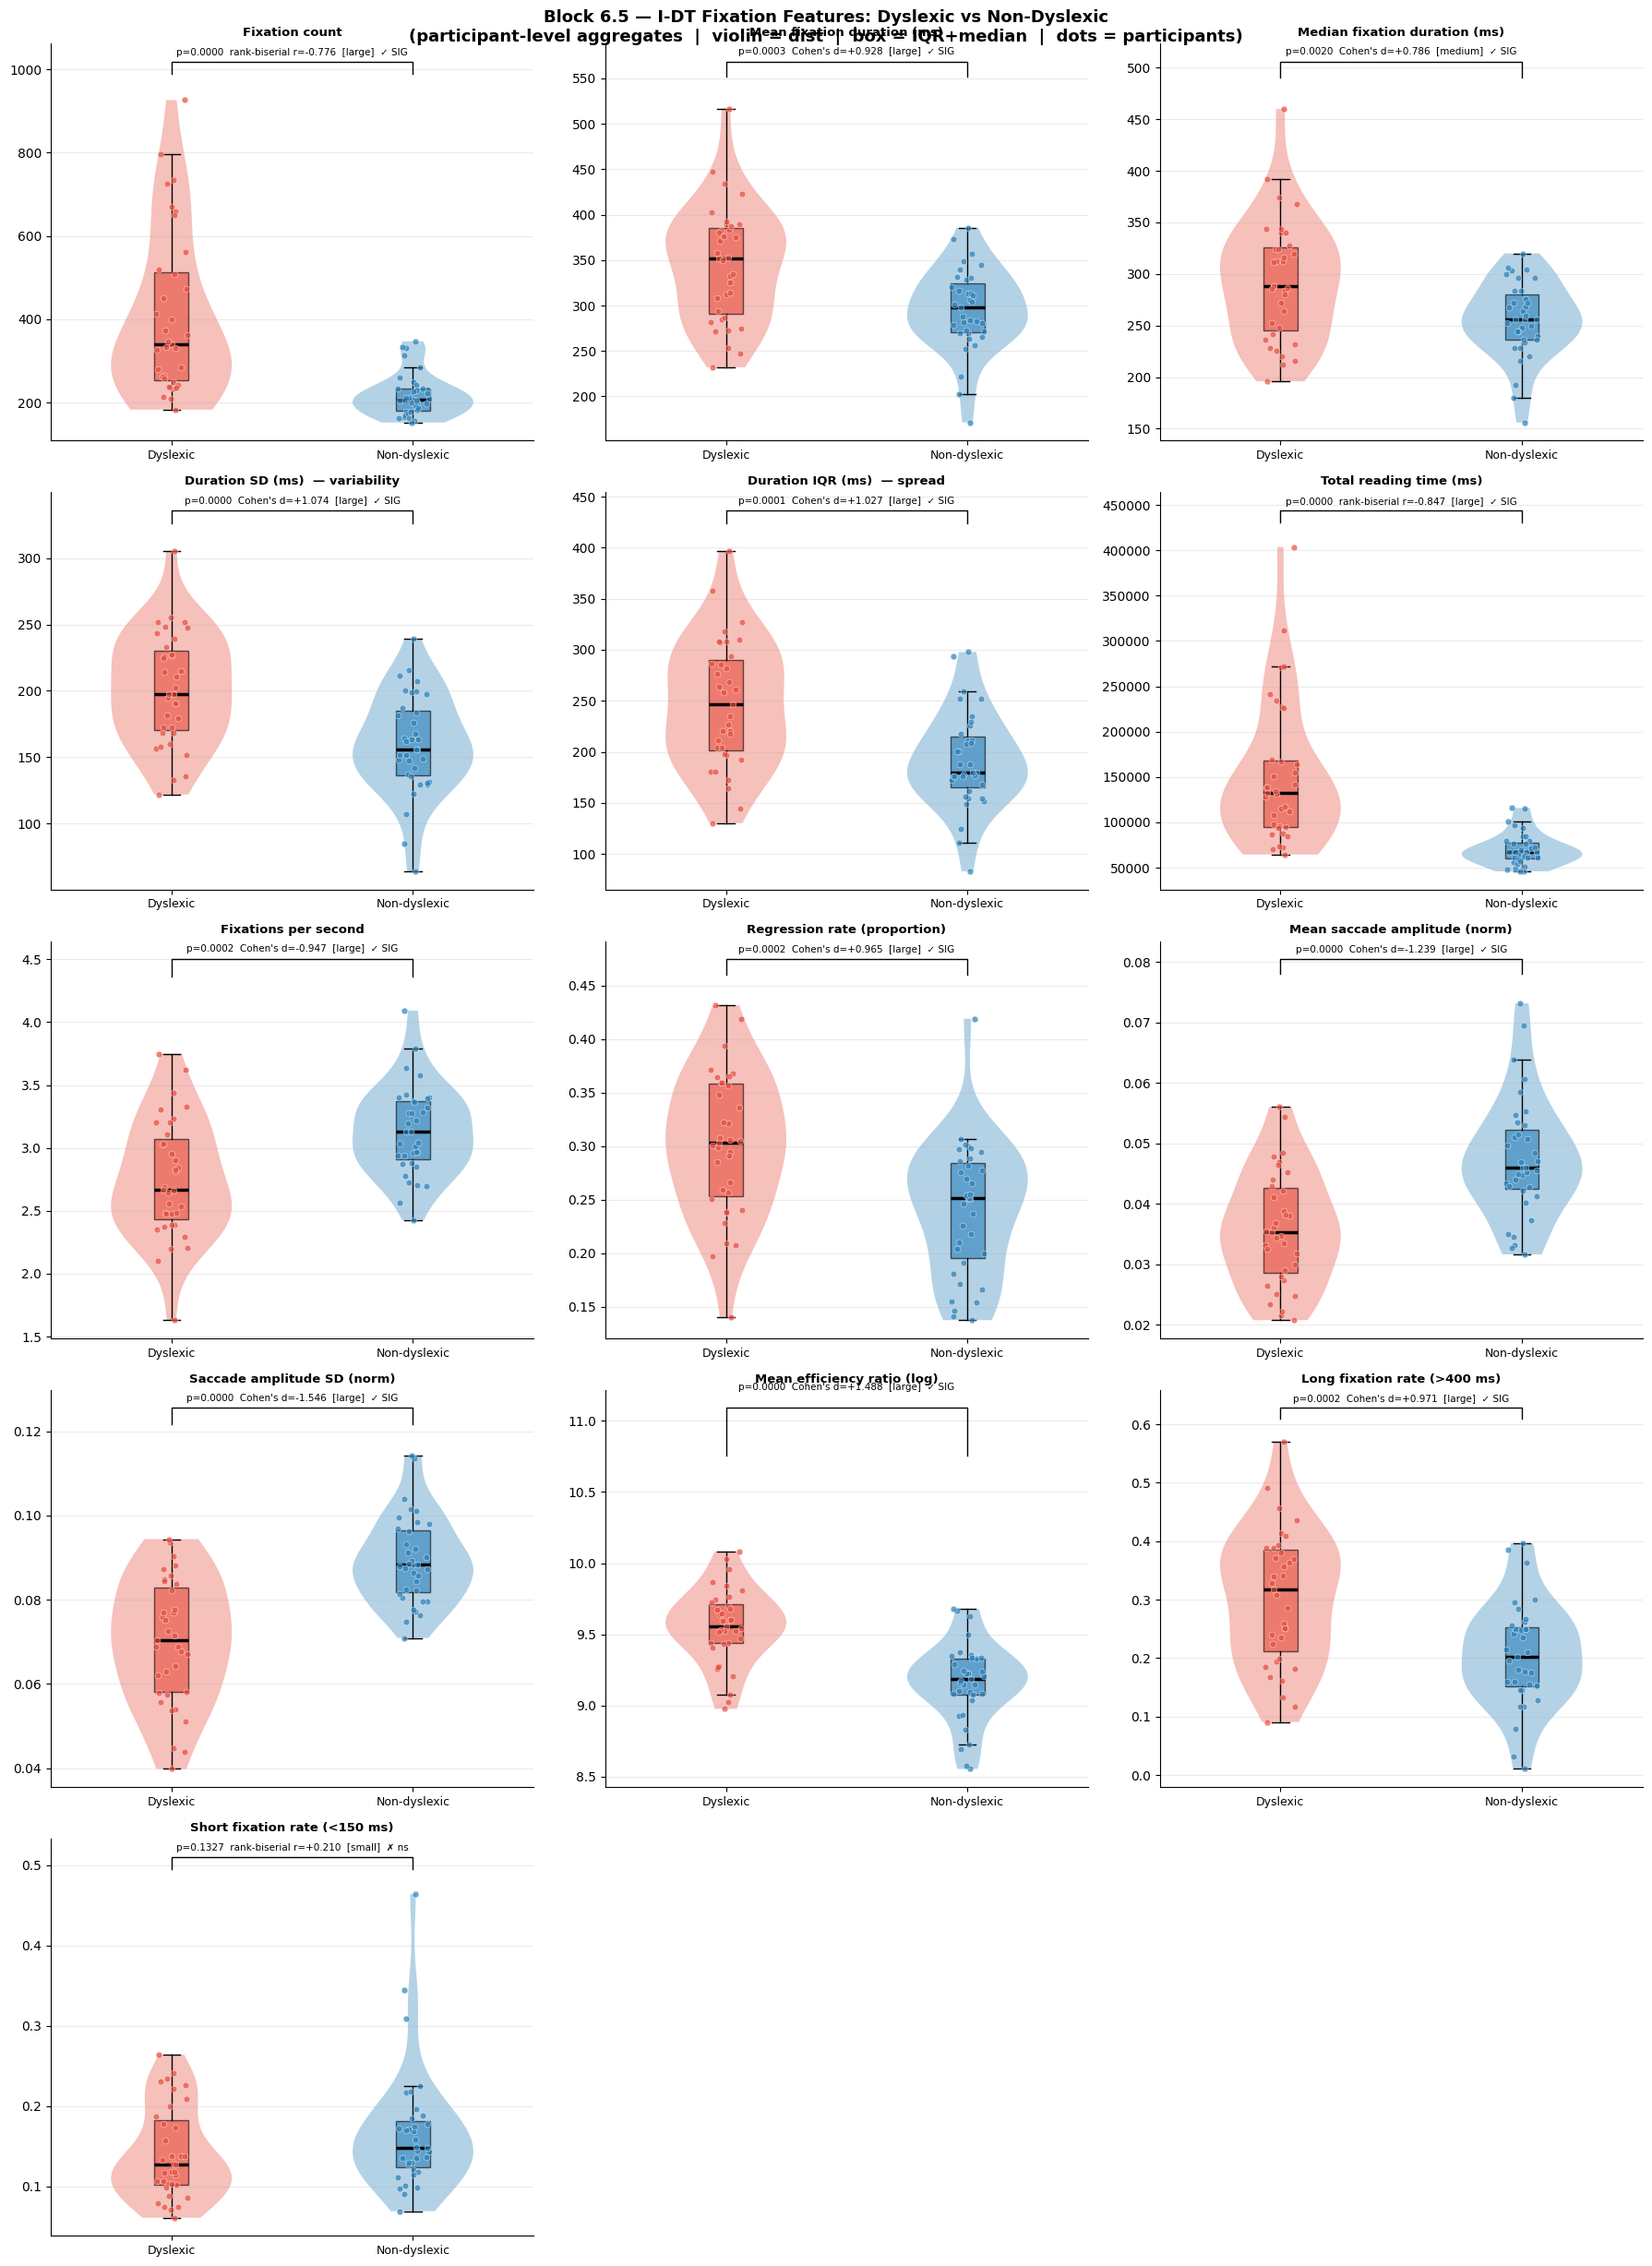

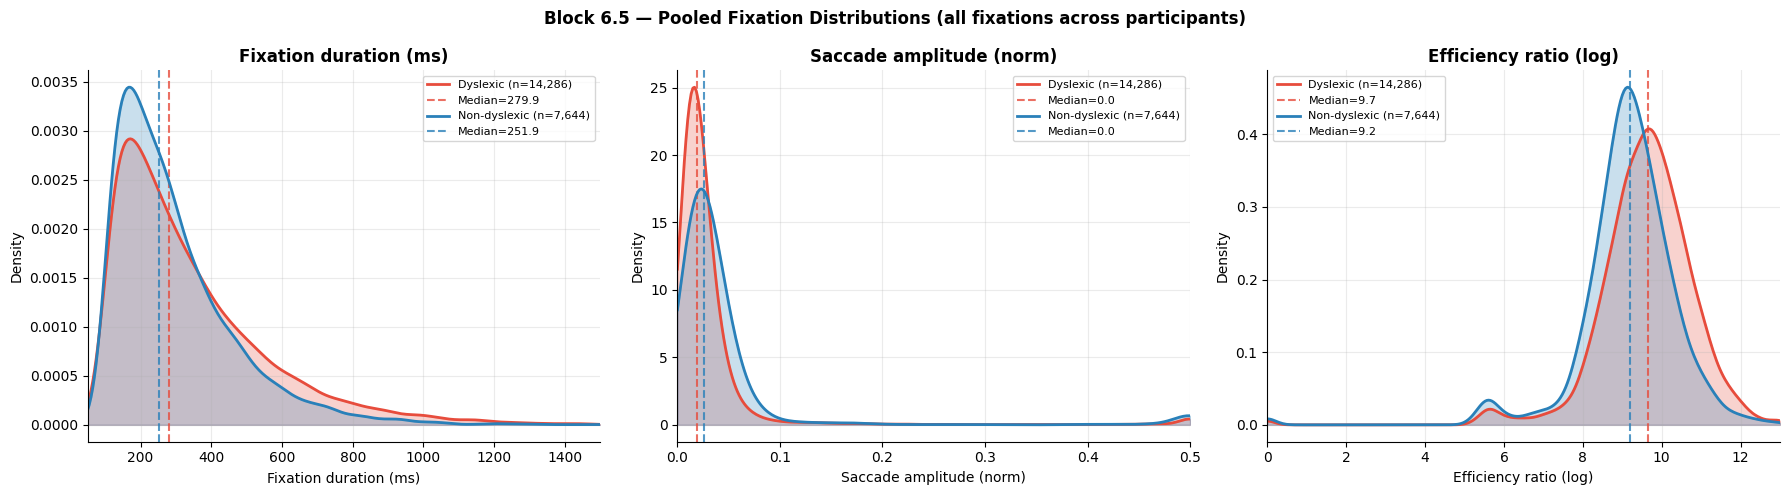

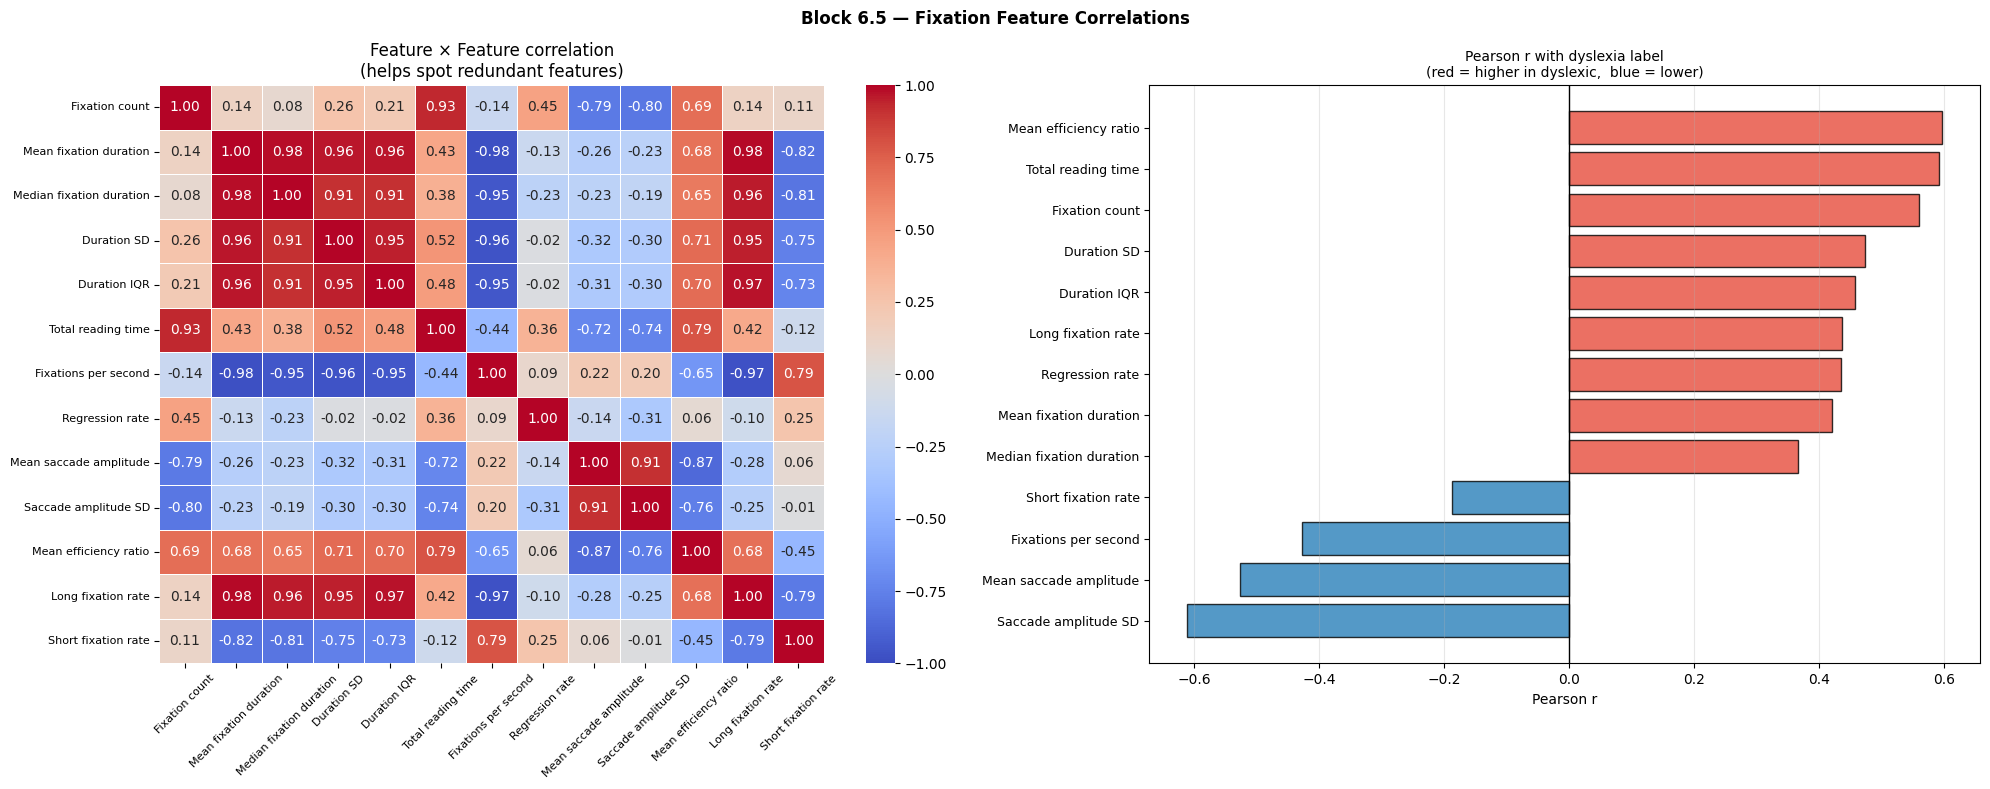


  Block 6.5 — Key Findings
  Significant (p < 0.0038): ['Fixation count', 'Mean fixation duration (ms)', 'Median fixation duration (ms)', 'Duration SD (ms)  — variability', 'Duration IQR (ms)  — spread', 'Total reading time (ms)', 'Fixations per second', 'Regression rate (proportion)', 'Mean saccade amplitude (norm)', 'Saccade amplitude SD (norm)', 'Mean efficiency ratio (log)', 'Long fixation rate (>400 ms)']
  Trend (p < .05)              : none

  Effect directions (dyslexic vs non-dyslexic):
    Saccade amplitude SD (norm)               : LOWER  (r/d=-1.546, large)
    Mean efficiency ratio (log)               : HIGHER  (r/d=+1.488, large)
    Mean saccade amplitude (norm)             : LOWER  (r/d=-1.239, large)
    Duration SD (ms)  — variability           : HIGHER  (r/d=+1.074, large)
    Duration IQR (ms)  — spread               : HIGHER  (r/d=+1.027, large)
    Long fixation rate (>400 ms)              : HIGHER  (r/d=+0.971, large)
Group column unique values: ['Non-dyslexic' 

In [23]:
print("--- Block 6.5: Fixation Features — Statistical Comparison Dyslexic vs Non-Dyslexic ---")

# ── 1. Build participant-level aggregate from I-DT fixations ─────────────────
# We re-run I-DT per participant to get the raw fixation table for analysis.
# (participant_packets already holds sequences, but we need pre-scaling fixations)

fix_records = []
for pid in tqdm(all_participant_ids, desc="Building fixation aggregates"):
    pattern = os.path.join(DATA_PATH, f'Subject_{pid}_{TASK_FILE_GLOB}')
    files   = glob.glob(pattern)
    if not files:
        continue
    try:
        gaze_df = load_and_clean_raw(files[0])
        fix_df  = detect_fixations_idt(gaze_df)
    except Exception as e:
        continue

    if len(fix_df) < 2:
        continue

    # Per-fixation amplitude
    dx = fix_df['fix_x_norm'].diff().fillna(0)
    dy = fix_df['fix_y_norm'].diff().fillna(0)
    fix_df['amplitude'] = np.sqrt(dx**2 + dy**2)
    fix_df.loc[fix_df.index[0], 'amplitude'] = 0.0

    # Per-fixation regression flag
    prev_x = fix_df['fix_x_norm'].shift(1)
    fix_df['is_regression'] = ((fix_df['fix_x_norm'] < prev_x) &
                                prev_x.notna()).astype(int)

    # Efficiency ratio
    safe_amp = np.maximum(fix_df['amplitude'].values, AMPLITUDE_FLOOR)
    raw_log  = np.log1p(fix_df['duration_ms'].values / safe_amp)
    is_first = prev_x.isna()
    fix_df['efficiency'] = np.where(is_first, 0.0,
                                     np.clip(raw_log, 0.0, EFFICIENCY_CAP))

    total_time = fix_df['onset_ms'].max() + fix_df['duration_ms'].iloc[-1]

    fix_records.append({
        'participant_id'       : pid,
        'label'                : labels_df.loc[pid, 'dyslexia_label'],
        'label_str'            : labels_df.loc[pid, 'dyslexia_label_str'],
        # --- aggregated features ---
        'n_fixations'          : len(fix_df),
        'mean_duration'        : fix_df['duration_ms'].mean(),
        'median_duration'      : fix_df['duration_ms'].median(),
        'std_duration'         : fix_df['duration_ms'].std(),
        'iqr_duration'         : (fix_df['duration_ms'].quantile(0.75) -
                                   fix_df['duration_ms'].quantile(0.25)),
        'total_reading_time_ms': total_time,
        'fix_per_sec'          : len(fix_df) / (total_time / 1000.0),
        'regression_rate'      : fix_df['is_regression'].mean(),
        'mean_amplitude'       : fix_df['amplitude'].iloc[1:].mean(),
        'std_amplitude'        : fix_df['amplitude'].iloc[1:].std(),
        'mean_efficiency'      : fix_df['efficiency'].iloc[1:].mean(),
        'std_efficiency'       : fix_df['efficiency'].iloc[1:].std(),
        'long_fix_rate'        : (fix_df['duration_ms'] > 400).mean(),  # % long fixations
        'short_fix_rate'       : (fix_df['duration_ms'] < 150).mean(),  # % short fixations
        # raw fixation table for distribution plots
        '_fix_df'              : fix_df,
    })

fix_agg_df = pd.DataFrame([{k: v for k, v in r.items() if k != '_fix_df'}
                             for r in fix_records])
dys_fix = fix_agg_df[fix_agg_df['label'] == 1]
ctl_fix = fix_agg_df[fix_agg_df['label'] == 0]
print(f"Participants — Dyslexic: {len(dys_fix)}  Non-dyslexic: {len(ctl_fix)}")

# ── 2. Pooled fixation distributions (all fixations across participants) ──────
all_fix_dys = pd.concat([r['_fix_df'].assign(group='Dyslexic')
                          for r in fix_records
                          if labels_df.loc[r['participant_id'], 'dyslexia_label'] == 1])
all_fix_ctl = pd.concat([r['_fix_df'].assign(group='Non-dyslexic')
                          for r in fix_records
                          if labels_df.loc[r['participant_id'], 'dyslexia_label'] == 0])
all_fix = pd.concat([all_fix_dys, all_fix_ctl], ignore_index=True)

# ── 3. Statistical tests on participant-level aggregates ──────────────────────
FIX_FEATURES = [
    ('n_fixations',           'Fixation count'),
    ('mean_duration',         'Mean fixation duration (ms)'),
    ('median_duration',       'Median fixation duration (ms)'),
    ('std_duration',          'Duration SD (ms)  — variability'),
    ('iqr_duration',          'Duration IQR (ms)  — spread'),
    ('total_reading_time_ms', 'Total reading time (ms)'),
    ('fix_per_sec',           'Fixations per second'),
    ('regression_rate',       'Regression rate (proportion)'),
    ('mean_amplitude',        'Mean saccade amplitude (norm)'),
    ('std_amplitude',         'Saccade amplitude SD (norm)'),
    ('mean_efficiency',       'Mean efficiency ratio (log)'),
    ('long_fix_rate',         'Long fixation rate (>400 ms)'),
    ('short_fix_rate',        'Short fixation rate (<150 ms)'),
]
N_FIX_FEATURES  = len(FIX_FEATURES)
ALPHA_CORRECTED_FIX = 0.05 / N_FIX_FEATURES

fix_results = []
for col, label in FIX_FEATURES:
    res = run_group_test(dys_fix[col].values, ctl_fix[col].values,
                         label, ALPHA_CORRECTED_FIX)
    fix_results.append(res)

# ── 4. Summary table ──────────────────────────────────────────────────────────
print(f"\n{'='*100}")
print(f"  Statistical Summary — I-DT Fixation Features  "
      f"(Bonferroni α = 0.05/{N_FIX_FEATURES} = {ALPHA_CORRECTED_FIX:.4f})")
print(f"{'='*100}")
print(f"  {'Feature':<40} {'Test':<18} {'p-val':>8} {'Effect':>8} {'Mag':<12} {'Sig'}")
print(f"  {'-'*94}")
for r in fix_results:
    print(f"  {r['feature']:<40} {r['test']:<18} {r['p_val']:>8.4f} "
          f"{r['effect']:>+8.3f}  {r['effect_mag']:<12} {r['significance']}")

print(f"\n  Descriptives (Dyslexic  |  Non-dyslexic):")
print(f"  {'Feature':<40} {'Dys mean':>10} {'Dys med':>10} {'Dys IQR':>10}"
      f" {'Ctl mean':>10} {'Ctl med':>10} {'Ctl IQR':>10}")
print(f"  {'-'*100}")
for r in fix_results:
    print(f"  {r['feature']:<40} {r['dys_mean']:>10.3f} {r['dys_median']:>10.3f} "
          f"{r['dys_iqr']:>10.3f} {r['ctl_mean']:>10.3f} {r['ctl_median']:>10.3f} "
          f"{r['ctl_iqr']:>10.3f}")

# ── 5. Violin + box + strip plots (participant-level) ─────────────────────────
fix_agg_df['Group'] = fix_agg_df['label_str'].map(
    {'dyslexic': 'Dyslexic', 'non-dyslexic': 'Non-dyslexic'}
)

n_cols = 3
n_rows = int(np.ceil(N_FIX_FEATURES / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()
fig.suptitle('Block 6.5 — I-DT Fixation Features: Dyslexic vs Non-Dyslexic\n'
             '(participant-level aggregates  |  violin = dist  |  box = IQR+median  |  dots = participants)',
             fontsize=13, fontweight='bold')

for ax_idx, (col, feat_label) in enumerate(FIX_FEATURES):
    ax  = axes[ax_idx]
    res = fix_results[ax_idx]

    groups_ordered = ['Dyslexic', 'Non-dyslexic']
    data_grouped = [fix_agg_df[fix_agg_df['Group'] == g][col].dropna().values
                    for g in groups_ordered]

    # Guard: skip violin if either group is empty or constant (all same value)
    if any(len(d) < 2 or d.std() == 0 for d in data_grouped):
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                transform=ax.transAxes, color='gray')
        ax.set_title(feat_label, fontsize=9.5, fontweight='bold')
        continue
        
    parts = ax.violinplot(data_grouped, positions=[0, 1],
                           showmedians=False, showextrema=False)
    for pc, color in zip(parts['bodies'], list(PALETTE.values())):
        pc.set_facecolor(color)
        pc.set_alpha(0.35)

    bp = ax.boxplot(data_grouped, positions=[0, 1], widths=0.14,
                     patch_artist=True, showfliers=False,
                     medianprops=dict(color='black', linewidth=2.5))
    for patch, color in zip(bp['boxes'], list(PALETTE.values())):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    for grp_idx, (grp_name, color) in enumerate(PALETTE.items()):
        vals   = fix_agg_df[fix_agg_df['Group'] == grp_name][col].dropna().values
        jitter = np.random.default_rng(99).uniform(-0.07, 0.07, len(vals))
        ax.scatter(np.full(len(vals), grp_idx) + jitter, vals,
                   color=color, alpha=0.7, s=24, zorder=4,
                   edgecolors='white', linewidths=0.4)

    y_max  = max(np.nanmax(fix_agg_df[col]), 1e-9)
    y_top  = y_max * 1.10
    sig_text = (f"p={res['p_val']:.4f}  {res['effect_name']}={res['effect']:+.3f}"
                f"  [{res['effect_mag']}]  {res['significance']}")
    ax.plot([0, 0, 1, 1], [y_top*0.97, y_top, y_top, y_top*0.97],
            color='black', lw=1)
    ax.text(0.5, y_top * 1.01, sig_text, ha='center', va='bottom',
            fontsize=7.5, color='black')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Dyslexic', 'Non-dyslexic'], fontsize=9)
    ax.set_title(feat_label, fontsize=9.5, fontweight='bold')
    ax.grid(True, alpha=0.25, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axes[N_FIX_FEATURES:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'block6_5_fixation_group_comparison.png'), dpi=150)
plt.show()

# ── 6. KDE overlay — pooled fixation distributions ───────────────────────────
KDE_FEATURES = [
    ('duration_ms', 'Fixation duration (ms)',      (50, 1500)),
    ('amplitude',   'Saccade amplitude (norm)',     (0, 0.5)),
    ('efficiency',  'Efficiency ratio (log)',        (0, 13)),
]
fig2, axes2 = plt.subplots(1, len(KDE_FEATURES), figsize=(6*len(KDE_FEATURES), 5))
fig2.suptitle('Block 6.5 — Pooled Fixation Distributions (all fixations across participants)',
              fontsize=12, fontweight='bold')

for ax, (col, label, xlim) in zip(axes2, KDE_FEATURES):
    for grp, color in PALETTE.items():
        data = all_fix[all_fix['group'] == grp][col].dropna()
        # KDE using scipy
        kde  = sp_stats.gaussian_kde(data.clip(*xlim), bw_method='silverman')
        xs   = np.linspace(xlim[0], xlim[1], 300)
        ax.fill_between(xs, kde(xs), alpha=0.25, color=color)
        ax.plot(xs, kde(xs), color=color, lw=2, label=f'{grp} (n={len(data):,})')
        ax.axvline(data.median(), color=color, linestyle='--', lw=1.5,
                   alpha=0.8, label=f'Median={data.median():.1f}')
    ax.set_xlim(xlim)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'block6_5_pooled_kde.png'), dpi=150)
plt.show()

# ── 7. Correlation heatmap (fixation features) ────────────────────────────────
feat_cols_fix = [c for c, _ in FIX_FEATURES]
corr_fix = fix_agg_df[feat_cols_fix + ['label']].corr()

fig3, axes3 = plt.subplots(1, 2, figsize=(20, 8))
fig3.suptitle('Block 6.5 — Fixation Feature Correlations', fontsize=12, fontweight='bold')

short_fix_labels = [l.split('(')[0].strip() for _, l in FIX_FEATURES]
sns.heatmap(corr_fix.loc[feat_cols_fix, feat_cols_fix],
            ax=axes3[0], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, vmin=-1, vmax=1,
            xticklabels=short_fix_labels, yticklabels=short_fix_labels)
axes3[0].set_title('Feature × Feature correlation\n(helps spot redundant features)')
axes3[0].tick_params(axis='x', rotation=45, labelsize=8)
axes3[0].tick_params(axis='y', labelsize=8)

label_corr_fix = corr_fix.loc[feat_cols_fix, 'label'].sort_values()
colors_bar_fix = ['#E74C3C' if v > 0 else '#2980B9' for v in label_corr_fix]
axes3[1].barh(range(len(label_corr_fix)), label_corr_fix.values,
               color=colors_bar_fix, edgecolor='black', alpha=0.8)
axes3[1].set_yticks(range(len(label_corr_fix)))
axes3[1].set_yticklabels(
    [short_fix_labels[feat_cols_fix.index(i)] for i in label_corr_fix.index],
    fontsize=9)
axes3[1].axvline(0, color='black', lw=1)
axes3[1].set_title('Pearson r with dyslexia label\n(red = higher in dyslexic,  blue = lower)',
                    fontsize=10)
axes3[1].set_xlabel('Pearson r')
axes3[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'block6_5_fixation_correlations.png'), dpi=150)
plt.show()

# ── 8. Final interpretation summary ───────────────────────────────────────────
print(f"\n{'='*70}")
print("  Block 6.5 — Key Findings")
print(f"{'='*70}")
sig_fix   = [r['feature'] for r in fix_results if '✓' in r['significance']]
trend_fix = [r['feature'] for r in fix_results if 'TREND' in r['significance']]
print(f"  Significant (p < {ALPHA_CORRECTED_FIX:.4f}): {sig_fix if sig_fix else 'none'}")
print(f"  Trend (p < .05)              : {trend_fix if trend_fix else 'none'}")
print()
print("  Effect directions (dyslexic vs non-dyslexic):")
for r in sorted(fix_results, key=lambda x: abs(x['effect']), reverse=True)[:6]:
    direction = "HIGHER" if r['effect'] > 0 else "LOWER"
    print(f"    {r['feature']:<42}: {direction}  "
          f"(r/d={r['effect']:+.3f}, {r['effect_mag']})")
print("Group column unique values:", fix_agg_df['Group'].unique())
print("Group value counts:\n", fix_agg_df['Group'].value_counts())
print("groups_ordered lookup:", groups_ordered)
print()
print(f"  Note: Tests run at participant level (N={len(fix_agg_df)}) to preserve")
print(f"  independence. Pooled KDE plots show all fixations for visual intuition")
print(f"  but are NOT used for inference (fixations within a participant are correlated).")

In [24]:
print("--- Block 6.8: Save Post-IDT Artefacts for Kaggle ---")
import os

# ── 1. Per-participant fixation CSVs ──────────────────────────────────────────
# These are the raw I-DT fixation tables (pre-scaling) — useful for
# any downstream analysis that needs the original ms values and coordinates.
FIX_CSV_DIR = os.path.join(OUTPUT_DIR, 'etdd70_fixations')
os.makedirs(FIX_CSV_DIR, exist_ok=True)

saved_fix = 0
for r in fix_records:
    pid    = r['participant_id']
    label  = r['label']
    fix_df = r['_fix_df'].copy()

    # Add metadata columns so each CSV is self-contained
    fix_df['participant_id'] = pid
    fix_df['dyslexia_label'] = label

    # Re-derive features so the CSV has everything in one place
    dx = fix_df['fix_x_norm'].diff().fillna(0)
    dy = fix_df['fix_y_norm'].diff().fillna(0)
    fix_df['amplitude_norm']  = np.sqrt(dx**2 + dy**2)
    fix_df.loc[fix_df.index[0], 'amplitude_norm'] = 0.0

    prev_x = fix_df['fix_x_norm'].shift(1)
    fix_df['is_regression'] = ((fix_df['fix_x_norm'] < prev_x) &
                                prev_x.notna()).astype(int)

    safe_amp = np.maximum(fix_df['amplitude_norm'].values, AMPLITUDE_FLOOR)
    fix_df['efficiency'] = np.where(
        prev_x.isna(), 0.0,
        np.clip(np.log1p(fix_df['duration_ms'].values / safe_amp), 0.0, EFFICIENCY_CAP)
    )

    out_path = os.path.join(FIX_CSV_DIR, f'Subject_{pid}_fixations.csv')
    fix_df.to_csv(out_path, index=False)
    saved_fix += 1

print(f"Saved {saved_fix} per-participant fixation CSVs → {FIX_CSV_DIR}/")

# ── 2. Participant-level aggregate stats table ─────────────────────────────────
agg_path = os.path.join(OUTPUT_DIR, 'etdd70_participant_aggregates.csv')
fix_agg_df.drop(columns=['Group'], errors='ignore').to_csv(agg_path, index=False)
print(f"Saved participant-level aggregate stats → {agg_path}")
print(f"  Shape: {fix_agg_df.shape}  (one row per participant, all features + label)")

# ── 3. Statistical test results table ─────────────────────────────────────────
stats_rows = []
for r in fix_results:
    stats_rows.append({
        'feature'       : r['feature'],
        'test'          : r['test'],
        'statistic'     : round(r['stat'], 4),
        'p_value'       : round(r['p_val'], 6),
        'effect_size'   : round(r['effect'], 4),
        'effect_type'   : r['effect_name'],
        'effect_mag'    : r['effect_mag'],
        'significant'   : '✓' in r['significance'],
        'dys_mean'      : round(r['dys_mean'], 4),
        'dys_median'    : round(r['dys_median'], 4),
        'dys_std'       : round(r['dys_std'], 4),
        'ctl_mean'      : round(r['ctl_mean'], 4),
        'ctl_median'    : round(r['ctl_median'], 4),
        'ctl_std'       : round(r['ctl_std'], 4),
    })
stats_df = pd.DataFrame(stats_rows)
stats_path = os.path.join(OUTPUT_DIR, 'etdd70_statistical_results.csv')
stats_df.to_csv(stats_path, index=False)
print(f"Saved statistical test results → {stats_path}")

--- Block 6.8: Save Post-IDT Artefacts for Kaggle ---
Saved 70 per-participant fixation CSVs → /kaggle/working/etdd70_fixations/
Saved participant-level aggregate stats → /kaggle/working/etdd70_participant_aggregates.csv
  Shape: (70, 18)  (one row per participant, all features + label)
Saved statistical test results → /kaggle/working/etdd70_statistical_results.csv


BLOCK 7 — Visualise raw sequences before padding

---
Key insight: we visualise the RAW sequence counts per participant so we can
see the actual distribution and understand what padding will look like.
We also check class balance at this stage.

---

--- Block 7: Raw Data Visualisation (Pre-Padding) ---


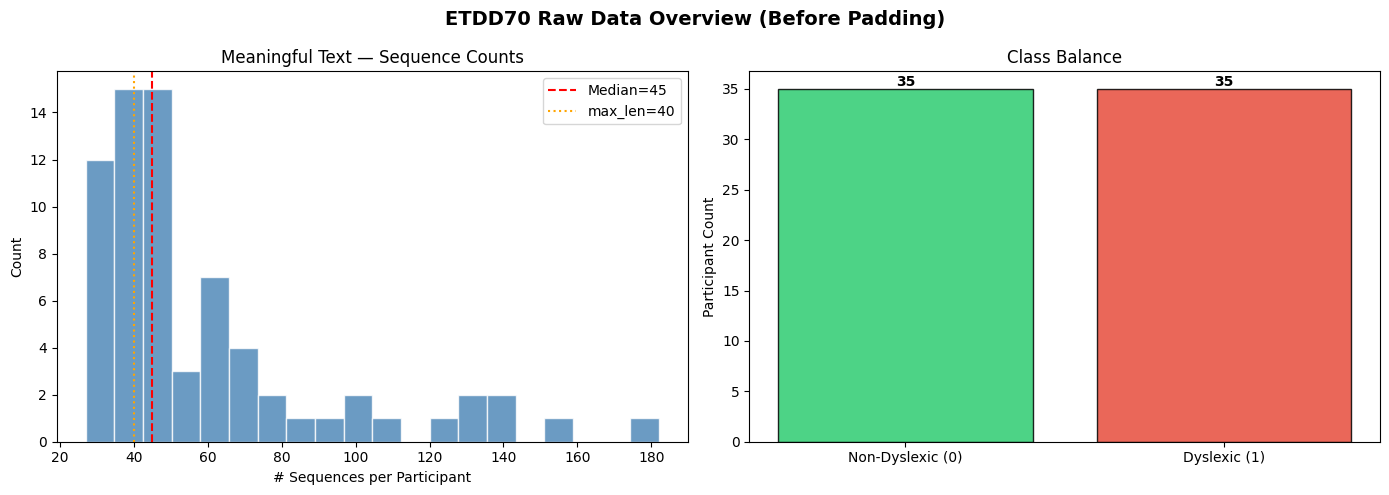


Aggregating feature distributions across all participants …


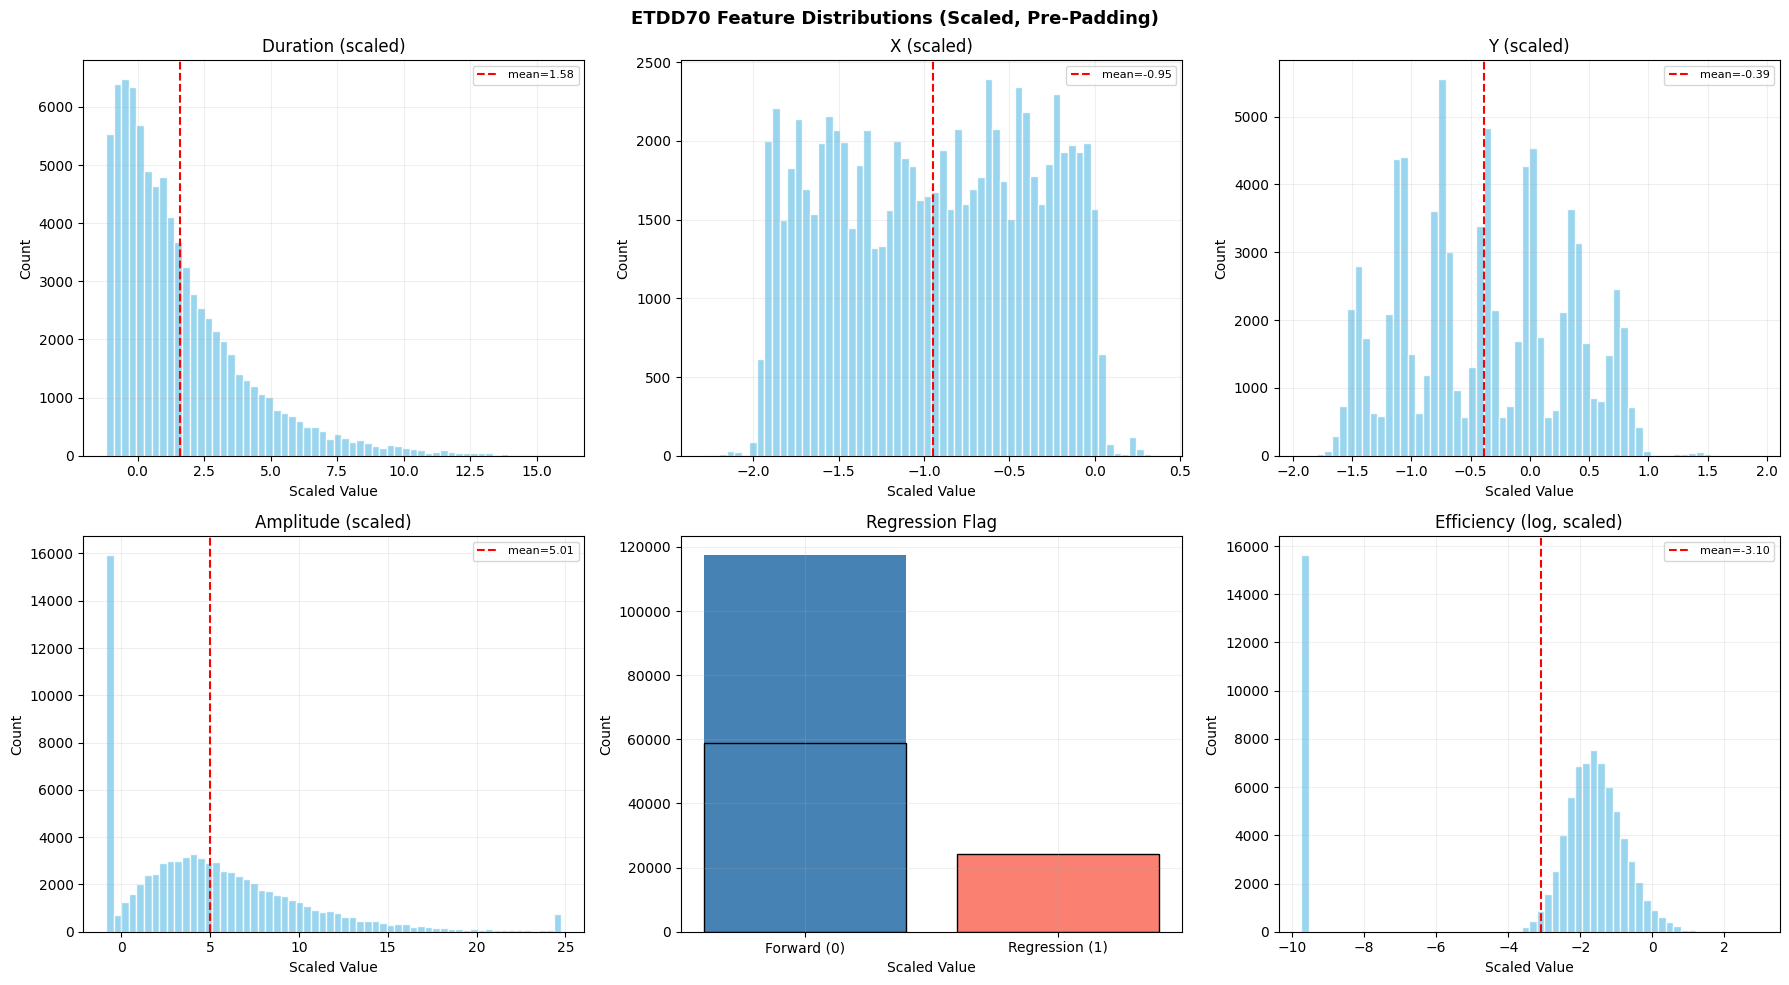


Descriptive stats (scaled features, 82,880 fixation-steps):
       Duration (scaled)  X (scaled)  Y (scaled)  Amplitude (scaled)  \
count          82880.000   82880.000   82880.000           82880.000   
mean               1.581      -0.948      -0.389               5.013   
std                2.481       0.584       0.683               5.123   
min               -1.183      -2.290      -1.928              -0.848   
5%                -0.987      -1.867      -1.459              -0.848   
25%               -0.206      -1.472      -1.005               1.138   
50%                0.871      -0.929      -0.393               4.230   
75%                2.630      -0.436       0.122               7.628   
95%                6.587      -0.062       0.741              14.585   
99%               10.352       0.025       0.879              23.678   
max               15.923       0.376       1.916              24.770   

       Regression Flag  Efficiency (log, scaled)  
count        82880.000 

In [25]:
print("--- Block 7: Raw Data Visualisation (Pre-Padding) ---")

# ── 7a. Sequence count distribution per task ─────────────────────────────────
mean_counts  = [len(p['sequences_meaningful']) for p in participant_packets]
labels_list  = [p['label']                     for p in participant_packets]

# Changed from 3 columns to 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ETDD70 Raw Data Overview (Before Padding)', fontsize=14, fontweight='bold')

# 1. Meaningful sequences
axes[0].hist(mean_counts, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(np.median(mean_counts), color='red', linestyle='--',
                label=f'Median={np.median(mean_counts):.0f}')
axes[0].axvline(max_len, color='orange', linestyle=':', label=f'max_len={max_len}')
axes[0].set_title('Meaningful Text — Sequence Counts')
axes[0].set_xlabel('# Sequences per Participant')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Class balance (Shifted to axes[1])
class_counts = pd.Series(labels_list).value_counts().sort_index()
axes[1].bar(['Non-Dyslexic (0)', 'Dyslexic (1)'],
            [class_counts.get(0, 0), class_counts.get(1, 0)],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
for i, v in enumerate([class_counts.get(0, 0), class_counts.get(1, 0)]):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')
axes[1].set_title('Class Balance')
axes[1].set_ylabel('Participant Count')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'etdd70_raw_overview.png'), dpi=150)
plt.show()

# ── 7b. Feature distributions — aggregate across all participants ─────────────
print("\nAggregating feature distributions across all participants …")
all_feats = []
for p in participant_packets:
    for seq_arr in [p['sequences_meaningful']]:
        if len(seq_arr) > 0:
            all_feats.append(seq_arr.reshape(-1, N_FEATURES))

if all_feats:
    feat_matrix = np.vstack(all_feats)
    feat_df = pd.DataFrame(feat_matrix, columns=[
        'Duration (scaled)', 'X (scaled)', 'Y (scaled)',
        'Amplitude (scaled)', 'Regression Flag', 'Efficiency (log, scaled)'
    ])

    fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
    axes2 = axes2.flatten()
    fig2.suptitle('ETDD70 Feature Distributions (Scaled, Pre-Padding)',
                  fontsize=13, fontweight='bold')

    for i, col in enumerate(feat_df.columns):
        if col == 'Regression Flag':
            axes2[i].bar([0, 1],
                         [(feat_df[col] < 0).sum() + (feat_df[col] < 0.5).sum(),
                          (feat_df[col] >= 0.5).sum()],
                         color=['steelblue', 'salmon'])
            # After scaling the binary flag is no longer {0,1} so count properly
            raw_reg = (feat_matrix[:, 4] > 0).sum()
            axes2[i].bar(['Forward (0)', 'Regression (1)'],
                         [len(feat_matrix) - raw_reg, raw_reg],
                         color=['steelblue', 'salmon'], edgecolor='black')
        else:
            axes2[i].hist(feat_df[col].values, bins=60,
                          color='skyblue', edgecolor='white', alpha=0.85)
            mean_v = feat_df[col].mean()
            axes2[i].axvline(mean_v, color='red', linestyle='--',
                             label=f'mean={mean_v:.2f}')
            axes2[i].legend(fontsize=8)
        axes2[i].set_title(col)
        axes2[i].set_xlabel('Scaled Value')
        axes2[i].set_ylabel('Count')
        axes2[i].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'etdd70_feature_distributions.png'), dpi=150)
    plt.show()
    print(f"\nDescriptive stats (scaled features, {len(feat_matrix):,} fixation-steps):")
    print(feat_df.describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(3))

# ── 7c. Padding waste analysis ────────────────────────────────────────────────
real_data_fraction = [c / max_len for c in mean_counts]
print(f"\nPadding analysis (Meaningful Text):")
print(f"  Median real-data fraction : {np.median(real_data_fraction):.2%}")
print(f"  Min real-data fraction    : {min(real_data_fraction):.2%}")
print(f"  → {100*(1-np.median(real_data_fraction)):.0f}% of tensor is padding on average")

BLOCK 8 — Smart Padding with Validity Masks

---
KEY FIX over old pipeline:
Old: pad zeros → encoder transforms zeros → dilutes GlobalAveragePooling
New: pad zeros + store boolean validity mask (True = real data)
GlobalAveragePooling uses the mask so padded slots contribute 0 weight

---
Shape after padding per participant:
X_mean  : (max_len, SEQUENCE_LENGTH, N_FEATURES)
X_pse   : (max_len, SEQUENCE_LENGTH, N_FEATURES)
mask_mean: (max_len,) — True for real sequence slots
mask_pse : (max_len,) — True for real sequence slots

---

In [26]:
print("--- Block 8: Stratified K-Fold Setup & Safe Data Prep ---")
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
all_pids   = np.array([p['participant_id'] for p in participant_packets])
all_labels = np.array([p['label']          for p in participant_packets])


def prepare_fold_data(train_pids, val_pids, packets, base_scaler, max_len):
    """
    Scales, adjusts, and pads data for a single fold.

    DATA LEAKAGE PREVENTION (Issue 5):
    ────────────────────────────────────────────────────────────────────────
    The Phase-1 scaler was fit on a different dataset (OneStop).
    For Amplitude (index 3) and Efficiency (index 5) — the two features
    whose distributions differ most between datasets — we refit mean and
    scale using ONLY the current fold's TRAINING participants.

    Duration, X, Y, Regression use Phase-1 stats as-is (these features
    are transferable: normalised screen coordinates and ms don't change).

    The fold_scaler is RETURNED so the best fold's scaler can be saved
    as the production artefact (Block 11.5), ensuring perfect consistency
    between the model's training environment and Phase-3 inference.

    Returns
    ──────
    train_inputs, y_train, val_inputs, y_val, fold_scaler
    """
    train_packets = [p for p in packets if p['participant_id'] in train_pids]
    val_packets   = [p for p in packets if p['participant_id'] in val_pids]

    OLD_AMP_MEAN  = base_scaler.mean_[3];  OLD_AMP_SCALE = base_scaler.scale_[3]
    OLD_EFF_MEAN  = base_scaler.mean_[5];  OLD_EFF_SCALE = base_scaler.scale_[5]

    # ── Compute fold-specific amplitude and efficiency stats from TRAIN only ──
    raw_amp_train, raw_eff_train = [], []
    for p in train_packets:
        seqs = p['sequences_meaningful']
        if len(seqs) == 0: continue
        raw_amp_flat = (seqs[:, :, 3].flatten() * OLD_AMP_SCALE) + OLD_AMP_MEAN
        raw_eff_flat = (seqs[:, :, 5].flatten() * OLD_EFF_SCALE) + OLD_EFF_MEAN
        raw_amp_train.extend(raw_amp_flat[raw_amp_flat != 0.0])
        raw_eff_train.extend(raw_eff_flat[raw_eff_flat != 0.0])

    NEW_AMP_MEAN  = np.mean(raw_amp_train);  NEW_AMP_SCALE = np.std(raw_amp_train)  + 1e-8
    NEW_EFF_MEAN  = np.mean(raw_eff_train);  NEW_EFF_SCALE = np.std(raw_eff_train)  + 1e-8

    # Fold-specific AMPLITUDE_MAX cap: 95th pct of THIS fold's training amplitudes.
    # Tighter than the global cap from Block 5.9, which was computed on all 70.
    FOLD_AMP_MAX = float(np.percentile(raw_amp_train, 95))

    fold_scaler = pickle.loads(pickle.dumps(base_scaler))
    fold_scaler.mean_[3]  = NEW_AMP_MEAN;   fold_scaler.scale_[3] = NEW_AMP_SCALE
    fold_scaler.mean_[5]  = NEW_EFF_MEAN;   fold_scaler.scale_[5] = NEW_EFF_SCALE

    def pad_and_mask(packets_list):
        X_list, mask_list, y_list = [], [], []
        for p in packets_list:
            seqs = p['sequences_meaningful'].copy()
            if len(seqs) == 0: continue

            raw_amp = (seqs[:, :, 3] * OLD_AMP_SCALE) + OLD_AMP_MEAN
            raw_eff = (seqs[:, :, 5] * OLD_EFF_SCALE) + OLD_EFF_MEAN

            raw_amp = np.clip(raw_amp, 0.0, FOLD_AMP_MAX)  # fold-specific cap

            seqs[:, :, 3] = (raw_amp - NEW_AMP_MEAN) / NEW_AMP_SCALE
            seqs[:, :, 5] = (raw_eff - NEW_EFF_MEAN) / NEW_EFF_SCALE

            n = len(seqs)
            padded = np.zeros((max_len, SEQUENCE_LENGTH, N_FEATURES), dtype=np.float32)
            mask   = np.zeros(max_len, dtype=np.float32)
            copy_n = min(n, max_len)
            padded[:copy_n] = seqs[:copy_n]
            mask[:copy_n]   = 1.0

            X_list.append(padded); mask_list.append(mask); y_list.append(p['label'])
        return np.array(X_list), np.array(mask_list), np.array(y_list)

    X_train, mask_train, y_train = pad_and_mask(train_packets)
    X_val,   mask_val,   y_val   = pad_and_mask(val_packets)

    train_inputs = {'input_meaningful': X_train, 'mask_meaningful': mask_train}
    val_inputs   = {'input_meaningful': X_val,   'mask_meaningful': mask_val}

    return train_inputs, y_train, val_inputs, y_val, fold_scaler  # ← now returns fold_scaler


print(f"Stratified {N_SPLITS}-Fold Cross Validation ready.")
print("prepare_fold_data() now returns fold_scaler for production artefact tracking (Issue 5).")
print("Fold-specific AMPLITUDE_MAX cap added (95th pct of training amplitudes per fold).")

--- Block 8: Stratified K-Fold Setup & Safe Data Prep ---
Stratified 5-Fold Cross Validation ready.
prepare_fold_data() now returns fold_scaler for production artefact tracking (Issue 5).
Fold-specific AMPLITUDE_MAX cap added (95th pct of training amplitudes per fold).


BLOCK 9 — Stratified Participant-Level Train / Validation Split

---
KEY FIX over old pipeline:
Old: simple random split — class balance not guaranteed
New: stratify=y so train/val have same dyslexic/non-dyslexic ratio
Also: print per-split balance so we can verify

---

BLOCK 10 — Build the "Reading Profile" Classification Model

---
Architecture:

---
[input_meaningful]  (N_ppts, max_len, 20, 6)
[input_pseudo]      (N_ppts, max_len, 20, 6)
[mask_meaningful]   (N_ppts, max_len)   ← validity masks
[mask_pseudo]       (N_ppts, max_len)

---
shared TimeDistributed(frozen_encoder) → (N_ppts, max_len, 64)

---
MaskedGlobalAvgPool (custom) → (N_ppts, 64)   ← excludes padding slots

---
Concatenate → (N_ppts, 128)
Dense(64, relu) → Dropout(0.5)
Dense(1, sigmoid)

---
KEY FIX: MaskedGlobalAveragePooling1D — padded slots (mask=0) are excluded
from the average, so they cannot dilute the real reading profile.

---

In [27]:
print("--- Block 10: Building Classification Model ---")

# Load frozen encoder
encoder = load_model(ENCODER_PATH)
encoder.trainable = False
print(f"Encoder loaded: {encoder.name}  (frozen)")
print(f"  Input : {encoder.input_shape}")
print(f"  Output: {encoder.output_shape}")

@tf.keras.utils.register_keras_serializable(package='Custom')
class MaskedGlobalAvgPool(tf.keras.layers.Layer):
    """
    Computes the mean of embeddings across the time dimension,
    excluding positions where mask == 0 (padded slots).

    Inputs:
        embeddings : (batch, max_len, embed_dim)
        mask       : (batch, max_len)  float32, 1=real, 0=padded

    Output:
        (batch, embed_dim)
    """
    def call(self, embeddings, mask):
        mask_exp  = tf.expand_dims(mask, -1)               # (B, T, 1)
        masked    = embeddings * mask_exp                   # zero padded slots
        sum_emb   = tf.reduce_sum(masked, axis=1)          # (B, D)
        count     = tf.reduce_sum(mask_exp, axis=1) + EPSILON  # (B, 1)
        return sum_emb / count                              # (B, D)


# In Block 10, update the build_classifier function:

def build_classifier(max_len: int,
                     encoder_model: tf.keras.Model,
                     seq_len: int = SEQUENCE_LENGTH,
                     n_features: int = N_FEATURES,
                     latent_dim: int = LATENT_DIM,
                     dropout_rate: float = 0.35): 
    
    input_mean = Input(shape=(max_len, seq_len, n_features), name='input_meaningful')
    mask_mean_in = Input(shape=(max_len,), name='mask_meaningful', dtype=tf.float32)
    
    shared_td = TimeDistributed(encoder_model, name='shared_gaze_encoder')
    encoded_mean = shared_td(input_mean) 
    
    masked_pool = MaskedGlobalAvgPool(name='masked_avg_pool')
    profile = masked_pool(encoded_mean, mask_mean_in) 
    
    # Increased dropout and added L2 regularization to the dense layers
    x = Dense(64, activation='relu', name='head_dense_1', 
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(profile)
    x = Dropout(0.3, name='head_dropout_1')(x)
    
    x = Dense(32, activation='relu', name='head_dense_2',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.2, name='head_dropout_2')(x) # INCREASED from 0.3 to 0.5
    
    output = Dense(1, activation='sigmoid', name='output_classifier')(x)
    
    return Model(
        inputs=[input_mean, mask_mean_in],
        outputs=output,
        name='reading_profile_classifier_v3'
    )


profile_model = build_classifier(max_len, encoder)
profile_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

print("\nModel summary:")
profile_model.summary()

--- Block 10: Building Classification Model ---


I0000 00:00:1781456748.824471      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Encoder loaded: gaze_encoder_v3  (frozen)
  Input : (None, 20, 6)
  Output: (None, 64)

Model summary:


Model: "reading_profile_classifier_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_meaningful    │ (None, 40, 20, 6) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_gaze_encoder │ (None, 40, 64)    │    151,872 │ input_meaningful… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_meaningful     │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_avg_pool     │ (None, 64)        │          0 │ shared_gaze_enco… │
│ (MaskedGlobalAvgPo… │                   │            │ mask_meaningful[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_1        │ (None, 64)        │      4,160 │ masked_avg_pool[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout_1      │ (None, 64)        │          0 │ head_dense_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_2        │ (None, 32)        │      2,080 │ head_dropout_1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout_2      │ (None, 32)        │          0 │ head_dense_2[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_classifier   │ (None, 1)         │         33 │ head_dropout_2[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 158,145 (617.75 KB)

 Trainable params: 6,273 (24.50 KB)

 Non-trainable params: 151,872 (593.25 KB)

BLOCK 11 — Train

---

In [28]:
def set_encoder_trainable(encoder_model, unfreeze_names: list):
    """Set encoder layer trainability and audit exactly which weights are unfrozen."""
    for layer in encoder_model.layers:
        layer.trainable = (layer.name in unfreeze_names)

    trainable = sum(tf.size(w).numpy() for w in encoder_model.trainable_weights)
    frozen    = sum(tf.size(w).numpy() for w in encoder_model.non_trainable_weights)
    print(f"  Encoder trainable: {trainable:,}  |  frozen: {frozen:,}")

    for layer in encoder_model.layers:
        if not layer.name.startswith('encoder_input'):
            tag = '✓ TRAIN' if layer.trainable else '  frozen'
            print(f"    {tag}  {layer.name}")

    # ── DIAGNOSTIC: Audit every trainable weight tensor ──────────────────
    # This prints the name, shape, and param count of each individual
    # weight tensor that will receive gradients. If you see weight names
    # like "state_proj_h/kernel" or "state_proj_c/kernel" here, it means
    # those Dense projection layers were placed inside the encoder graph
    # instead of the decoder graph — inflating the param count.
    if trainable > 0:
        print(f"    ── Trainable weight audit ──")
        for layer in encoder_model.layers:
            if layer.trainable and hasattr(layer, 'weights') and layer.weights:
                for w in layer.weights:
                    n_params = int(np.prod(w.shape))
                    print(f"      weight: {w.name}  shape={w.shape}  params={n_params:,}")

In [29]:
print("--- Block 11: K-Fold Training with Conditional Gradual Fine-Tuning ---")
import os, math, pickle
import tensorflow as tf
from sklearn.metrics import roc_auc_score, f1_score

tf.get_logger().setLevel('ERROR')

# ── Training constants ─────────────────────────────────────────────────────────
BATCH_SIZE_TRAIN = 16
# Previous BATCH_SIZE = n_train = 56 gave exactly 1 step/epoch.
# With BATCH_SIZE=16 and 56 participants we get ~3-4 steps/epoch → ~8x more
# gradient updates for the same epoch budget, and genuine stochastic regularisation.
# This is the primary reason Phase 2a/2b never fired before — one step/epoch was
# not enough signal for the encoder's weights to adjust on such small data.

LR_HEAD       = 2e-4    # Phase 1: head only
LR_FINETUNE_A = 5e-6    # Phase 2a: encoder_lstm_2 (smaller than previous 1e-5 —
                         # with mini-batches each step is more informative, so a
                         # smaller LR prevents overshooting)
LR_FINETUNE_B = 1e-6    # Phase 2b: MHSA block added — very conservative given
                         # 82K encoder params vs 56 training samples

CLIP_HEAD     = 1.0
CLIP_FINETUNE = 0.5      # tighter clip for encoder fine-tuning

EPOCHS_PHASE1  = 150
EPOCHS_PHASE2A = 100
EPOCHS_PHASE2B = 60

UNFREEZE_2A = ['encoder_lstm_2']
UNFREEZE_2B = ['encoder_mhsa', 'encoder_residual', 'encoder_layernorm']

# ── Best-fold tracking (Issues 4 & 5) ─────────────────────────────────────────
# These four variables let Block 13.5 build the canonical Phase-3 source split
# from the BEST fold's exact PID partition (Issue 4) using the BEST fold's
# scaler (Issue 5) — instead of always defaulting to Fold 1's split.
best_overall_auc     = 0.0
best_model_path_overall = os.path.join(OUTPUT_DIR, 'best_reading_profile_v3_kfold.keras')
best_fold_idx        = 0      # 0-based index into list(skf.split(...))
best_fold_scaler     = None   # fold_scaler from prepare_fold_data for the best fold
best_fold_train_pids = None   # exact PIDs in the best fold's train partition
best_fold_val_pids   = None   # exact PIDs in the best fold's val partition

fold_metrics = []


def set_encoder_trainable(encoder_model, unfreeze_names):
    for layer in encoder_model.layers:
        layer.trainable = (layer.name in unfreeze_names)
    trainable = sum(tf.size(w).numpy() for w in encoder_model.trainable_weights)
    frozen    = sum(tf.size(w).numpy() for w in encoder_model.non_trainable_weights)
    print(f"  Encoder trainable: {trainable:,}  |  frozen: {frozen:,}")
    for layer in encoder_model.layers:
        if not layer.name.startswith('encoder_input'):
            tag = '✓ TRAIN' if layer.trainable else '  frozen'
            print(f"    {tag}  {layer.name}")


def compile_model(model, lr, clipnorm):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )


def make_callbacks(fold_ckpt, phase_name):
    """
    Returns [EarlyStopping, ReduceLROnPlateau, ModelCheckpoint].

    WHY DIFFERENT METRICS FOR EarlyStopping vs ModelCheckpoint? (Issue 6)
    ─────────────────────────────────────────────────────────────────────────
    With only 14 validation participants, val_auc is DISCRETE — it can take
    at most ~91 distinct values (all combinations of 14 binary predictions).
    One misclassified participant shifts AUC by ~0.07, making it a coin-flip
    stopping signal: a true learning plateau looks identical to a lucky epoch.

    val_loss (binary cross-entropy) uses raw predicted probabilities, NOT rank
    order — so it is genuinely continuous. Even when the AUC ranking does not
    change, val_loss CAN decrease as probabilities move further from 0.5 toward
    their correct labels. This gives EarlyStopping a much smoother, more
    reliable signal to distinguish "still improving" from "plateaued."

    min_delta=0.002 filters out numerical noise (< 0.2% BCE change) so ES
    does not mistake tiny floating-point fluctuations for genuine improvement.

    patience is phase-specific: Phase 1 gets the most patience (25 epochs)
    because it trains from scratch; fine-tuning phases use less (20 / 15)
    since they start from already-converged weights and are expected to either
    improve quickly or not at all.

    ModelCheckpoint uses val_auc — because DISCRIMINATION is our actual
    scientific metric. We always want to save the weights with the best
    class-ranking performance, regardless of when ES fires.

    restore_best_weights=False on EarlyStopping: we ALWAYS load from the
    checkpoint manually at the end of each phase. This guarantees we load
    the best-val_auc weights rather than the weights at the ES trigger epoch
    (which could be a later, slightly worse epoch that val_loss was still
    monotonically decreasing on).
    """
    patience_map = {'Phase1': 25, 'Phase2a': 20, 'Phase2b': 15}
    patience = patience_map.get(phase_name, 20)

    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',          # continuous → smooth stopping signal
            patience=patience,
            mode='min',
            min_delta=0.002,             # only count as improvement if BCE drops ≥0.2%
            restore_best_weights=False,  # always load checkpoint manually (see above)
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=max(patience // 3, 5),
            mode='min',
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=fold_ckpt,
            monitor='val_auc',           # save the best-RANKING model
            save_best_only=True,
            mode='max',
            verbose=0,
        ),
    ]


# ── K-Fold loop ────────────────────────────────────────────────────────────────
for fold, (train_idx, val_idx) in enumerate(skf.split(all_pids, all_labels)):
    print(f"\n{'='*64}")
    print(f"FOLD {fold + 1} / {N_SPLITS}")
    print(f"{'='*64}")

    train_pids = all_pids[train_idx]
    val_pids   = all_pids[val_idx]

    # prepare_fold_data now returns fold_scaler (Issue 5)
    train_inputs, y_train, val_inputs, y_val, fold_scaler = prepare_fold_data(
        train_pids, val_pids, participant_packets, scaler, max_len
    )

    n_train      = len(y_train)
    steps_per_ep = math.ceil(n_train / BATCH_SIZE_TRAIN)
    print(f"\n  n_train={n_train}  BATCH_SIZE={BATCH_SIZE_TRAIN}  "
          f"→ {steps_per_ep} steps/epoch  "
          f"(was 1 step/epoch with full-batch)")
    print(f"  class: {int(y_train.sum())} dys / {int((y_train==0).sum())} ctl")

    fold_ckpt = f'/tmp/fold_{fold + 1}_best.keras'

    # Load fresh encoder for each fold
    encoder = load_model(
        ENCODER_PATH,
        custom_objects={'MaskedGlobalAvgPool': MaskedGlobalAvgPool}
    )
    set_encoder_trainable(encoder, unfreeze_names=[])
    profile_model = build_classifier(max_len, encoder)

    # ─────────────────────────────────────────────────────────────────────────
    # PHASE 1 — Head only, encoder fully frozen
    # ─────────────────────────────────────────────────────────────────────────
    print(f"\n── Phase 1: Head only, encoder frozen  [{EPOCHS_PHASE1} epoch budget] ──")
    compile_model(profile_model, lr=LR_HEAD, clipnorm=CLIP_HEAD)
    profile_model.fit(
        train_inputs, y_train,
        epochs=EPOCHS_PHASE1,
        batch_size=BATCH_SIZE_TRAIN,
        validation_data=(val_inputs, y_val),
        callbacks=make_callbacks(fold_ckpt, 'Phase1'),
        verbose=1,
    )
    phase1_best_auc = max(profile_model.history.history.get('val_auc', [0]))
    print(f"  Phase 1 best val_auc: {phase1_best_auc:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # PHASE 2a — Unfreeze encoder_lstm_2 only (conditional on Phase 1 quality)
    #
    # Guard: skip if Phase 1 AUC < 0.55 (barely above chance). Fine-tuning
    # an encoder whose head hasn't learned anything useful is pointless.
    #
    # With mini-batches this phase now gets ~3-4x more gradient steps per epoch
    # than in all previous runs, which is why we're testing it again here.
    # ─────────────────────────────────────────────────────────────────────────
    print(f"\n── Phase 2a: encoder_lstm_2 fine-tune  [{EPOCHS_PHASE2A} epoch budget] ──")
    if phase1_best_auc < 0.55:
        print(f"  ⚠  Phase 1 AUC {phase1_best_auc:.4f} < 0.55 — "
              f"skipping fine-tuning for this fold (head too weak).")
        phase2a_best_auc = phase1_best_auc
    else:
        set_encoder_trainable(encoder, unfreeze_names=UNFREEZE_2A)
        compile_model(profile_model, lr=LR_FINETUNE_A, clipnorm=CLIP_FINETUNE)
        profile_model.fit(
            train_inputs, y_train,
            epochs=EPOCHS_PHASE2A,
            batch_size=BATCH_SIZE_TRAIN,
            validation_data=(val_inputs, y_val),
            callbacks=make_callbacks(fold_ckpt, 'Phase2a'),
            verbose=1,
        )
        phase2a_best_auc = max(profile_model.history.history.get('val_auc', [0]))
        improved_2a = phase2a_best_auc > phase1_best_auc

        print(f"  Phase 2a best val_auc: {phase2a_best_auc:.4f}  "
              f"({'↑ improved' if improved_2a else '→ no gain, rolling back to Phase 1 checkpoint'})")

        if not improved_2a:
            # Roll back to the Phase-1 best checkpoint
            profile_model = load_model(
                fold_ckpt,
                custom_objects={'MaskedGlobalAvgPool': MaskedGlobalAvgPool}
            )
            encoder = profile_model.get_layer('shared_gaze_encoder').layer
            phase2a_best_auc = phase1_best_auc   # report Phase-1 score as the baseline

    # ─────────────────────────────────────────────────────────────────────────
    # PHASE 2b — MHSA block + LSTM-2 (conditional on Phase 2a improvement)
    #
    # Only attempted when Phase 2a genuinely improved. MHSA has ~33K params
    # and LayerNorm has ~256; together with LSTM-2 (49K) this is ~82K trainable
    # encoder params on 56 samples — very high param:sample ratio.
    # LR_FINETUNE_B = 1e-6 and CLIP_FINETUNE = 0.5 keep updates micro-small.
    # ─────────────────────────────────────────────────────────────────────────
    print(f"\n── Phase 2b: MHSA + LSTM-2 fine-tune  [{EPOCHS_PHASE2B} epoch budget] ──")
    if phase2a_best_auc <= phase1_best_auc:
        print(f"  Skipping Phase 2b — Phase 2a showed no gain.")
        phase2b_best_auc = phase2a_best_auc
    else:
        set_encoder_trainable(encoder, unfreeze_names=UNFREEZE_2A + UNFREEZE_2B)
        compile_model(profile_model, lr=LR_FINETUNE_B, clipnorm=CLIP_FINETUNE)
        profile_model.fit(
            train_inputs, y_train,
            epochs=EPOCHS_PHASE2B,
            batch_size=BATCH_SIZE_TRAIN,
            validation_data=(val_inputs, y_val),
            callbacks=make_callbacks(fold_ckpt, 'Phase2b'),
            verbose=1,
        )
        phase2b_best_auc = max(profile_model.history.history.get('val_auc', [0]))
        improved_2b = phase2b_best_auc > phase2a_best_auc
        print(f"  Phase 2b best val_auc: {phase2b_best_auc:.4f}  "
              f"({'↑ improved' if improved_2b else '→ no gain'})")

        if not improved_2b:
            profile_model = load_model(
                fold_ckpt,
                custom_objects={'MaskedGlobalAvgPool': MaskedGlobalAvgPool}
            )
            encoder = profile_model.get_layer('shared_gaze_encoder').layer

    # ─────────────────────────────────────────────────────────────────────────
    # EVALUATE — always load from checkpoint (best val_auc across all phases)
    # ─────────────────────────────────────────────────────────────────────────
    print(f"\n── Evaluating Fold {fold + 1} (best checkpoint) ──")
    best_fold_model = load_model(
        fold_ckpt,
        custom_objects={'MaskedGlobalAvgPool': MaskedGlobalAvgPool}
    )
    fold_preds = best_fold_model.predict(
        val_inputs, batch_size=len(y_val), verbose=0
    ).ravel()

    fold_auc = roc_auc_score(y_val, fold_preds)
    best_f1, best_thresh = 0.0, 0.5
    for thresh in np.arange(0.30, 0.71, 0.01):
        preds_t = (fold_preds > thresh).astype(int)
        f1_t    = f1_score(y_val, preds_t, zero_division=0)
        if f1_t > best_f1:
            best_f1, best_thresh = f1_t, thresh

    print(f"  Val AUC : {fold_auc:.4f}")
    print(f"  Best F1 : {best_f1:.4f}  (threshold = {best_thresh:.2f})")
    print(f"  Phase aucs: P1={phase1_best_auc:.4f}  "
          f"P2a={phase2a_best_auc:.4f}  P2b={phase2b_best_auc:.4f}")

    fold_metrics.append({
        'fold': fold + 1, 'auc': fold_auc, 'f1': best_f1, 'threshold': best_thresh,
        'phase1_auc': phase1_best_auc,
        'phase2a_auc': phase2a_best_auc,
        'phase2b_auc': phase2b_best_auc,
    })

    # ── Track best fold for Issues 4 & 5 ──────────────────────────────────
    if fold_auc > best_overall_auc:
        best_overall_auc     = fold_auc
        best_fold_idx        = fold                                        # 0-based
        best_fold_scaler     = pickle.loads(pickle.dumps(fold_scaler))    # deep copy
        best_fold_train_pids = train_pids.copy()
        best_fold_val_pids   = val_pids.copy()
        print(f"  ★ New best overall AUC (Fold {fold + 1}) — saving to "
              f"{best_model_path_overall}")
        best_fold_model.save(best_model_path_overall)

    if os.path.exists(fold_ckpt):
        os.remove(fold_ckpt)

# ── Final summary ──────────────────────────────────────────────────────────────
tf.get_logger().setLevel('WARNING')
print(f"\n{'='*64}")
print("K-Fold Training Complete")
print(f"{'='*64}")
aucs = [m['auc'] for m in fold_metrics]
f1s  = [m['f1']  for m in fold_metrics]
print(f"{'Fold':<6} {'AUC':>8} {'F1':>8} {'Thresh':>8} "
      f"{'P1':>8} {'P2a':>8} {'P2b':>8}")
print("-" * 64)
for m in fold_metrics:
    print(f"{m['fold']:<6} {m['auc']:>8.4f} {m['f1']:>8.4f} "
          f"{m['threshold']:>8.2f} {m['phase1_auc']:>8.4f} "
          f"{m['phase2a_auc']:>8.4f} {m['phase2b_auc']:>8.4f}")
print("-" * 64)
print(f"{'Mean':<6} {np.mean(aucs):>8.4f} {np.mean(f1s):>8.4f}")
print(f"{'Std':<6} {np.std(aucs):>8.4f}  {np.std(f1s):>8.4f}")
print(f"{'Best':<6} {max(aucs):>8.4f} {max(f1s):>8.4f}")
print(f"\nBest model: Fold {best_fold_idx + 1}  AUC={best_overall_auc:.4f}")
print(f"  Train PIDs ({len(best_fold_train_pids)}): {sorted(best_fold_train_pids)}")
print(f"  Val   PIDs ({len(best_fold_val_pids )}): {sorted(best_fold_val_pids)}")

--- Block 11: K-Fold Training with Conditional Gradual Fine-Tuning ---

FOLD 1 / 5

  n_train=56  BATCH_SIZE=16  → 4 steps/epoch  (was 1 step/epoch with full-batch)
  class: 28 dys / 28 ctl
  Encoder trainable: 0  |  frozen: 151,872
      frozen  encoder_lstm_1
      frozen  encoder_dropout_1
      frozen  encoder_mhsa
      frozen  encoder_attention_dropout
      frozen  encoder_residual
      frozen  encoder_layernorm
      frozen  encoder_post_norm_dropout
      frozen  encoder_lstm_2

── Phase 1: Head only, encoder frozen  [150 epoch budget] ──
Epoch 1/150


I0000 00:00:1781456799.212800     181 cuda_dnn.cc:529] Loaded cuDNN version 91002


4/4 ━━━━━━━━━━━━━━━━━━━━ 63s 4s/step - accuracy: 0.5390 - auc: 0.5075 - loss: 0.7159 - precision: 0.8933 - recall: 0.1572 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7113 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.0000e-04
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.5372 - auc: 0.6564 - loss: 0.6928 - precision: 0.6367 - recall: 0.1460 - val_accuracy: 0.5000 - val_auc: 0.3571 - val_loss: 0.7104 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.0000e-04
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.4762 - auc: 0.4555 - loss: 0.7185 - precision: 0.2514 - recall: 0.0595 - val_accuracy: 0.5000 - val_auc: 0.4286 - val_loss: 0.7098 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.0000e-04
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.4390 - auc: 0.4040 - loss: 0.7308 - precision: 0.2693 - recall: 0.1082 - val_accuracy: 0.5000 - val_auc: 0.5816 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 36 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



── Phase 2b: MHSA + LSTM-2 fine-tune  [60 epoch budget] ──
  Skipping Phase 2b — Phase 2a showed no gain.

── Evaluating Fold 1 (best checkpoint) ──
  Val AUC : 0.8367
  Best F1 : 0.8750  (threshold = 0.39)
  Phase aucs: P1=0.8673  P2a=0.8673  P2b=0.8673
  ★ New best overall AUC (Fold 1) — saving to /kaggle/working/best_reading_profile_v3_kfold.keras

FOLD 2 / 5

  n_train=56  BATCH_SIZE=16  → 4 steps/epoch  (was 1 step/epoch with full-batch)
  class: 28 dys / 28 ctl
  Encoder trainable: 0  |  frozen: 151,872
      frozen  encoder_lstm_1
      frozen  encoder_dropout_1
      frozen  encoder_mhsa
      frozen  encoder_attention_dropout
      frozen  encoder_residual
      frozen  encoder_layernorm
      frozen  encoder_post_norm_dropout
      frozen  encoder_lstm_2

── Phase 1: Head only, encoder frozen  [150 epoch budget] ──
Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.5479 - auc: 0.3643 - loss: 0.7368 - precision: 0.5479 - recall: 1.0000 - val_accuracy: 0.5000 - val

...

  Val AUC : 1.0000
  Best F1 : 1.0000  (threshold = 0.52)
  Phase aucs: P1=1.0000  P2a=1.0000  P2b=1.0000
  ★ New best overall AUC (Fold 2) — saving to /kaggle/working/best_reading_profile_v3_kfold.keras

FOLD 3 / 5

  n_train=56  BATCH_SIZE=16  → 4 steps/epoch  (was 1 step/epoch with full-batch)
  class: 28 dys / 28 ctl
  Encoder trainable: 0  |  frozen: 151,872
      frozen  encoder_lstm_1
      frozen  encoder_dropout_1
      frozen  encoder_mhsa
      frozen  encoder_attention_dropout
      frozen  encoder_residual
      frozen  encoder_layernorm
      frozen  encoder_post_norm_dropout
      frozen  encoder_lstm_2

── Phase 1: Head only, encoder frozen  [150 epoch budget] ──
Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.3705 - auc: 0.2866 - loss: 0.7267 - precision: 0.3863 - recall: 0.5595 - val_accuracy: 0.6429 - val_auc: 0.5510 - val_loss: 0.7029 - val_precision: 0.7500 - val_recall: 0.4286 - learning_rate: 2.0000e-04
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 36 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  Val AUC : 0.8980
  Best F1 : 0.8571  (threshold = 0.53)
  Phase aucs: P1=0.9286  P2a=0.9286  P2b=0.9286

FOLD 4 / 5

  n_train=56  BATCH_SIZE=16  → 4 steps/epoch  (was 1 step/epoch with full-batch)
  class: 28 dys / 28 ctl
  Encoder trainable: 0  |  frozen: 151,872
      frozen  encoder_lstm_1
      frozen  encoder_dropout_1
      frozen  encoder_mhsa
      frozen  encoder_attention_dropout
      frozen  encoder_residual
      frozen  encoder_layernorm
      frozen  encoder_post_norm_dropout
      frozen  encoder_lstm_2

── Phase 1: Head only, encoder frozen  [150 epoch budget] ──
Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.5351 - auc: 0.5111 - loss: 0.7025 - precision: 0.5237 - recall: 0.7619 - val_accuracy: 0.5000 - val_auc: 0.6122 - val_loss: 0.7026 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 2.0000e-04
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.4783 - auc: 0.5401 - loss: 0.7019 - precision: 0.4976 - recall: 0.8132 - val_a

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 36 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  Val AUC : 1.0000
  Best F1 : 1.0000  (threshold = 0.47)
  Phase aucs: P1=1.0000  P2a=1.0000  P2b=1.0000

K-Fold Training Complete
Fold        AUC       F1   Thresh       P1      P2a      P2b
----------------------------------------------------------------
1        0.8367   0.8750     0.39   0.8673   0.8673   0.8673
2        1.0000   1.0000     0.52   1.0000   1.0000   1.0000
3        0.8980   0.8571     0.53   0.9286   0.9286   0.9286
4        0.7959   0.8000     0.40   0.7857   0.7959   0.7959
5        1.0000   1.0000     0.47   1.0000   1.0000   1.0000
----------------------------------------------------------------
Mean     0.9061   0.9064
Std      0.0832    0.0803
Best     1.0000   1.0000

Best model: Fold 2  AUC=1.0000
  Train PIDs (56): [np.int64(1003), np.int64(1009), np.int64(1019), np.int64(1021), np.int64(1033), np.int64(1038), np.int64(1040), np.int64(1058), np.int64(1065), np.int64(1090), np.int64(1109), np.int64(1113), np.int64(1115), np.int64(1145), np.int64(1160), np.i

In [30]:
print("--- Block 11.5: Save Production Scalers ---")
# ─────────────────────────────────────────────────────────────────────────────
# Two scalers are produced here for different purposes:
#
# 1. scaler_v3_etdd70_final.pkl  ← PRODUCTION scaler for the k-fold best model
#    This is BEST FOLD's fold_scaler — the exact scaler whose amplitude/efficiency
#    stats (mean and scale) the saved best-model's weights were calibrated with.
#
#    WHY NOT recompute a fresh global scaler here?
#    The model's Dense layers encode an implicit amplitude/efficiency scale in
#    their weights. If we recompute stats from all 70 participants, the resulting
#    mean/std may differ from the fold's stats, producing slightly mis-scaled
#    inputs at inference time. Small difference, but unnecessary: we already have
#    the exact scaler from training — just save it.
#
# 2. scaler_v3_etdd70_global.pkl ← scaler for the all-70 model (Block 12.5)
#    Computed from all 70 participants. Since the all-70 model has no fold split,
#    there is no fold_scaler — the global stats are the natural and only choice.
#    This is also what Phase 3 uses for webcam (target) data: a single consistent
#    scaling reference that doesn't depend on any particular fold partition.
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Save best-fold scaler as production artefact ──────────────────────────
production_scaler_path = os.path.join(OUTPUT_DIR, 'scaler_v3_etdd70_final.pkl')
with open(production_scaler_path, 'wb') as f:
    pickle.dump(best_fold_scaler, f)
print(f"Production scaler (Fold {best_fold_idx + 1}) → {production_scaler_path}")
print(f"  Amplitude : mean={best_fold_scaler.mean_[3]:.6f}  "
      f"scale={best_fold_scaler.scale_[3]:.6f}")
print(f"  Efficiency: mean={best_fold_scaler.mean_[5]:.6f}  "
      f"scale={best_fold_scaler.scale_[5]:.6f}")

# ── 2. Compute and save global scaler ────────────────────────────────────────
OLD_AMP_MEAN  = scaler.mean_[3];  OLD_AMP_SCALE = scaler.scale_[3]
OLD_EFF_MEAN  = scaler.mean_[5];  OLD_EFF_SCALE = scaler.scale_[5]

all_raw_amp, all_raw_eff = [], []
for p in participant_packets:
    seqs = p['sequences_meaningful']
    if len(seqs) == 0: continue
    raw_amp_flat = (seqs[:, :, 3].flatten() * OLD_AMP_SCALE) + OLD_AMP_MEAN
    raw_eff_flat = (seqs[:, :, 5].flatten() * OLD_EFF_SCALE) + OLD_EFF_MEAN
    all_raw_amp.extend(raw_amp_flat[raw_amp_flat != 0.0])
    all_raw_eff.extend(raw_eff_flat[raw_eff_flat != 0.0])

global_scaler = pickle.loads(pickle.dumps(scaler))
global_scaler.mean_[3]  = np.mean(all_raw_amp)
global_scaler.scale_[3] = np.std(all_raw_amp) + 1e-8
global_scaler.mean_[5]  = np.mean(all_raw_eff)
global_scaler.scale_[5] = np.std(all_raw_eff) + 1e-8
GLOBAL_AMP_MAX = float(np.percentile(all_raw_amp, 95))

global_scaler_path = os.path.join(OUTPUT_DIR, 'scaler_v3_etdd70_global.pkl')
with open(global_scaler_path, 'wb') as f:
    pickle.dump(global_scaler, f)
print(f"\nGlobal scaler (all 70) → {global_scaler_path}")
print(f"  Amplitude : mean={global_scaler.mean_[3]:.6f}  "
      f"scale={global_scaler.scale_[3]:.6f}")
print(f"  Efficiency: mean={global_scaler.mean_[5]:.6f}  "
      f"scale={global_scaler.scale_[5]:.6f}")
print(f"  GLOBAL_AMP_MAX (95th pct, all 70): {GLOBAL_AMP_MAX:.6f}")

print(f"\nDelta (fold vs global):")
for feat, idx in [('Amplitude mean', 3), ('Amplitude scale', 3),
                   ('Efficiency mean', 5), ('Efficiency scale', 5)]:
    key = 'mean_' if 'mean' in feat else 'scale_'
    bfs = best_fold_scaler.mean_[idx] if 'mean' in feat else best_fold_scaler.scale_[idx]
    gls = global_scaler.mean_[idx]    if 'mean' in feat else global_scaler.scale_[idx]
    print(f"  {feat:20s}: fold={bfs:.6f}  global={gls:.6f}  Δ={bfs-gls:+.6f}")

--- Block 11.5: Save Production Scalers ---
Production scaler (Fold 2) → /kaggle/working/scaler_v3_etdd70_final.pkl
  Amplitude : mean=0.017706  scale=0.015532
  Efficiency: mean=7.891748  scale=3.873096

Global scaler (all 70) → /kaggle/working/scaler_v3_etdd70_global.pkl
  Amplitude : mean=0.017604  scale=0.015388
  Efficiency: mean=7.887557  scale=3.891776
  GLOBAL_AMP_MAX (95th pct, all 70): 0.046356

Delta (fold vs global):
  Amplitude mean      : fold=0.017706  global=0.017604  Δ=+0.000102
  Amplitude scale     : fold=0.015532  global=0.015388  Δ=+0.000144
  Efficiency mean     : fold=7.891748  global=7.887557  Δ=+0.004190
  Efficiency scale    : fold=3.873096  global=3.891776  Δ=-0.018680


BLOCK 12 — Evaluation & Visualisation

---

--- Block 12: Final K-Fold Results Summary ---
Best overall model loaded from /kaggle/working/best_reading_profile_v3_kfold.keras
Final production scaler loaded from /kaggle/working/scaler_v3_etdd70_final.pkl


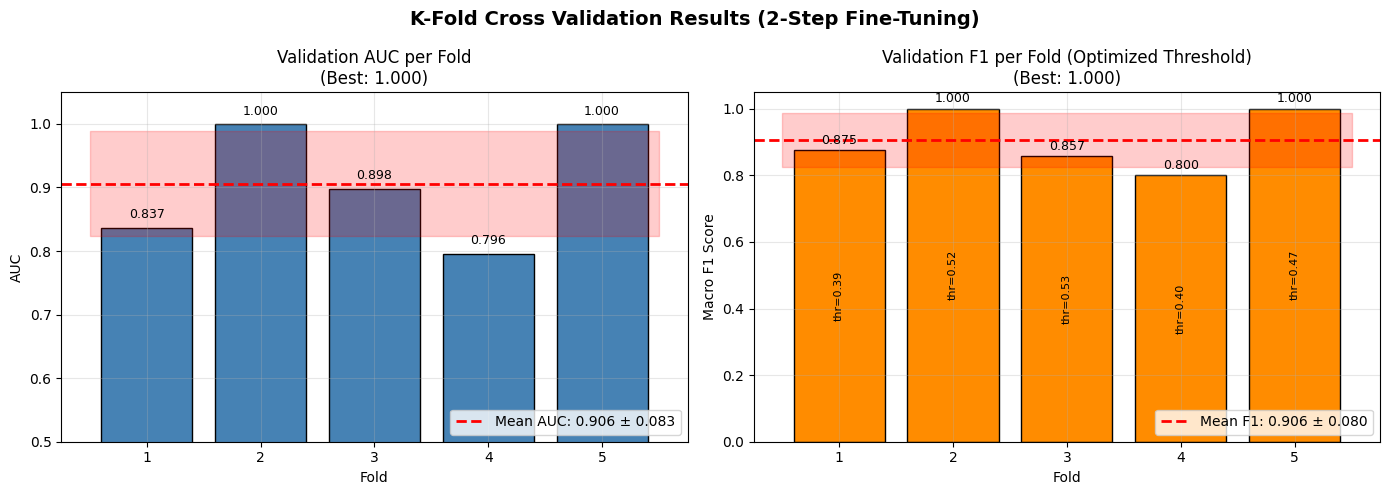


K-FOLD CROSS-VALIDATION SUMMARY
Fold   AUC      F1 Score   Threshold 
----------------------------------------
1      0.8367   0.8750       0.39
2      1.0000   1.0000       0.52
3      0.8980   0.8571       0.53
4      0.7959   0.8000       0.40
5      1.0000   1.0000       0.47
----------------------------------------
Mean   0.9061   0.9064
Std    0.0832   0.0803
Best   1.0000   1.0000

Metrics saved to /kaggle/working/kfold_metrics_v3.csv

Loaded Model Summary:
Inputs: [(None, 40, 20, 6), (None, 40)]
Output shape: (None, 1)
Total parameters: 158,145


In [31]:
print("--- Block 12: Final K-Fold Results Summary ---")

# IMPORTANT: Re-define the custom layer with serialization support before loading
# (This must be done even if it was defined in Block 10)
@tf.keras.utils.register_keras_serializable()
class MaskedGlobalAvgPool(tf.keras.layers.Layer):
    """
    Computes the mean of embeddings across the time dimension,
    excluding positions where mask == 0 (padded slots).

    Inputs:
        embeddings : (batch, max_len, embed_dim)
        mask       : (batch, max_len)  float32, 1=real, 0=padded

    Output:
        (batch, embed_dim)
    """
    def __init__(self, **kwargs):
        super(MaskedGlobalAvgPool, self).__init__(**kwargs)
    
    def call(self, inputs, mask=None):
        # Handle both list input and separate arguments
        if isinstance(inputs, (list, tuple)):
            embeddings, mask = inputs
        else:
            embeddings = inputs
            # mask should be passed separately, but if not, assume no masking
            if mask is None:
                mask = tf.ones(tf.shape(embeddings)[:2], dtype=tf.float32)
        
        EPSILON = 1e-9
        mask_exp = tf.expand_dims(mask, -1)               # (B, T, 1)
        masked = embeddings * mask_exp                    # zero padded slots
        sum_emb = tf.reduce_sum(masked, axis=1)           # (B, D)
        count = tf.reduce_sum(mask_exp, axis=1) + EPSILON # (B, 1)
        return sum_emb / count                            # (B, D)
    
    def get_config(self):
        config = super(MaskedGlobalAvgPool, self).get_config()
        return config

# Load the best model from the entire K-Fold process
# The custom_objects parameter ensures Keras knows about our custom layer
best_model = tf.keras.models.load_model(
    best_model_path_overall,
    custom_objects={'MaskedGlobalAvgPool': MaskedGlobalAvgPool}
)
print(f"Best overall model loaded from {best_model_path_overall}")

# Also load the final scaler for reference
final_scaler_path = os.path.join(OUTPUT_DIR, 'scaler_v3_etdd70_final.pkl')
with open(final_scaler_path, 'rb') as f:
    final_scaler = pickle.load(f)
print(f"Final production scaler loaded from {final_scaler_path}")

# Plotting K-Fold AUC and F1 distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Fold Cross Validation Results (2-Step Fine-Tuning)', fontsize=14, fontweight='bold')

# AUC per fold
auc_vals = [m['auc'] for m in fold_metrics]
f1_vals = [m['f1'] for m in fold_metrics]
thresholds = [m.get('threshold', 0.5) for m in fold_metrics]

# AUC plot
bars1 = axes[0].bar(range(1, N_SPLITS+1), auc_vals, color='steelblue', edgecolor='black')
axes[0].axhline(np.mean(auc_vals), color='red', linestyle='--', linewidth=2, 
                label=f'Mean AUC: {np.mean(auc_vals):.3f} ± {np.std(auc_vals):.3f}')
axes[0].fill_between([0.5, N_SPLITS+0.5], 
                     np.mean(auc_vals) - np.std(auc_vals), 
                     np.mean(auc_vals) + np.std(auc_vals), 
                     alpha=0.2, color='red')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('AUC')
axes[0].set_title(f'Validation AUC per Fold\n(Best: {max(auc_vals):.3f})')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0.5, 1.05)
axes[0].grid(True, alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars1, auc_vals)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# F1 per fold
bars2 = axes[1].bar(range(1, N_SPLITS+1), f1_vals, color='darkorange', edgecolor='black')
axes[1].axhline(np.mean(f1_vals), color='red', linestyle='--', linewidth=2,
                label=f'Mean F1: {np.mean(f1_vals):.3f} ± {np.std(f1_vals):.3f}')
axes[1].fill_between([0.5, N_SPLITS+0.5], 
                     np.mean(f1_vals) - np.std(f1_vals), 
                     np.mean(f1_vals) + np.std(f1_vals), 
                     alpha=0.2, color='red')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Macro F1 Score')
axes[1].set_title(f'Validation F1 per Fold (Optimized Threshold)\n(Best: {max(f1_vals):.3f})')
axes[1].legend(loc='lower right')
axes[1].set_ylim(0.0, 1.05)
axes[1].grid(True, alpha=0.3)

# Add value labels on bars
for i, (bar, val, thresh) in enumerate(zip(bars2, f1_vals, thresholds)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    # Add threshold info for the best folds
    if val > 0.7:  # Only show for good folds to avoid clutter
        axes[1].annotate(f'thr={thresh:.2f}', 
                        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()/2),
                        ha='center', va='center', fontsize=8, rotation=90)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kfold_evaluation_summary_v3.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print detailed summary
print("\n" + "="*60)
print("K-FOLD CROSS-VALIDATION SUMMARY")
print("="*60)
print(f"{'Fold':<6} {'AUC':<8} {'F1 Score':<10} {'Threshold':<10}")
print("-"*40)
for m in fold_metrics:
    print(f"{m['fold']:<6} {m['auc']:.4f}   {m['f1']:.4f}       {m.get('threshold', 0.5):.2f}")
print("-"*40)
print(f"{'Mean':<6} {np.mean(auc_vals):.4f}   {np.mean(f1_vals):.4f}")
print(f"{'Std':<6} {np.std(auc_vals):.4f}   {np.std(f1_vals):.4f}")
print(f"{'Best':<6} {max(auc_vals):.4f}   {max(f1_vals):.4f}")
print("="*60)

# Optional: Save metrics to CSV for later analysis
import pandas as pd
metrics_df = pd.DataFrame(fold_metrics)
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'kfold_metrics_v3.csv'), index=False)
print(f"\nMetrics saved to {os.path.join(OUTPUT_DIR, 'kfold_metrics_v3.csv')}")

# Optional: Quick model summary to verify loaded model
print("\nLoaded Model Summary:")
print(f"Inputs: {[inp.shape for inp in best_model.inputs]}")
print(f"Output shape: {best_model.output_shape}")
print(f"Total parameters: {best_model.count_params():,}")

BLOCK 13 — Save artefacts

---
best_reading_profile_v3.keras   ← full classifier (Phase-3 UDA input)
X_train_source.npy              ← (N_ppts_train, 2, max_len, 20, 6)
stacked mean+pseudo for UDA discriminator
X_val_source.npy
y_train_source.npy
y_val_source.npy

---

In [32]:
print("--- Block 12.5: Train Final Model on All 70 Participants ---")
# ─────────────────────────────────────────────────────────────────────────────
# PURPOSE: produce the PRODUCTION ENCODER for Phase 3 MMD.
#
# WHY train on all 70?
# Each k-fold model saw only 56 of 70 participants during training — 14 were
# always held out for validation. The encoder therefore lacks exposure to those
# 14 participants' reading patterns. For Phase 3 MMD the encoder needs to
# generalise as broadly as possible across the source domain. Training on all
# 70 gives it maximum source diversity.
#
# Scientific performance is reported from Block 11's k-fold AUC (honest
# out-of-sample estimate). THIS model is NOT used for performance reporting.
#
# ARCHITECTURE: Phase 1 only (head + frozen encoder).
# We do not fine-tune the encoder on all-70 data because:
#   (a) No held-out val set → no way to know if fine-tuning helped or overfit.
#   (b) A frozen-encoder all-70 model already has a better-generalised head
#       than any single fold. That head quality is what Phase 3's classification
#       loss will build on top of during MMD training.
#
# STOPPING without a val set:
# We use ReduceLROnPlateau on TRAIN loss. The epoch budget (EPOCHS_PHASE1 + 30)
# gives a safe margin above the average best epoch observed in k-fold while
# ensuring we don't waste compute on a permanently plateaued loss.
#
# SCALER: global_scaler (Block 11.5) — the only sensible choice when there
# is no fold split. Phase 3 target data also uses global_scaler → consistent.
# ─────────────────────────────────────────────────────────────────────────────

N_EPOCHS_ALL70 = EPOCHS_PHASE1 + 30   # generous budget; ReduceLROnPlateau handles convergence
print(f"Epoch budget: {N_EPOCHS_ALL70}  (Phase 1 budget + 30 buffer)")
print(f"Scaler: global_scaler (all-70 amplitude/efficiency stats)")

# ── Build training tensors ────────────────────────────────────────────────────
print("\nBuilding all-70 training tensors with global_scaler …")

OLD_AMP_MEAN  = scaler.mean_[3];          OLD_AMP_SCALE = scaler.scale_[3]
OLD_EFF_MEAN  = scaler.mean_[5];          OLD_EFF_SCALE = scaler.scale_[5]
NEW_AMP_MEAN  = global_scaler.mean_[3];   NEW_AMP_SCALE = global_scaler.scale_[3]
NEW_EFF_MEAN  = global_scaler.mean_[5];   NEW_EFF_SCALE = global_scaler.scale_[5]

X_all70_list, mask_all70_list, y_all70_list = [], [], []
for p in participant_packets:
    seqs = p['sequences_meaningful'].copy()
    if len(seqs) == 0:
        continue
    raw_amp = (seqs[:, :, 3] * OLD_AMP_SCALE) + OLD_AMP_MEAN
    raw_eff = (seqs[:, :, 5] * OLD_EFF_SCALE) + OLD_EFF_MEAN
    raw_amp = np.clip(raw_amp, 0.0, GLOBAL_AMP_MAX)
    seqs[:, :, 3] = (raw_amp - NEW_AMP_MEAN) / NEW_AMP_SCALE
    seqs[:, :, 5] = (raw_eff - NEW_EFF_MEAN) / NEW_EFF_SCALE

    n      = len(seqs)
    padded = np.zeros((max_len, SEQUENCE_LENGTH, N_FEATURES), dtype=np.float32)
    mask   = np.zeros(max_len, dtype=np.float32)
    copy_n = min(n, max_len)
    padded[:copy_n] = seqs[:copy_n];  mask[:copy_n] = 1.0
    X_all70_list.append(padded); mask_all70_list.append(mask); y_all70_list.append(p['label'])

X_all70    = np.array(X_all70_list,    dtype=np.float32)
mask_all70 = np.array(mask_all70_list, dtype=np.float32)
y_all70    = np.array(y_all70_list)
print(f"  X_all70: {X_all70.shape}  "
      f"class: {y_all70.sum()} dys / {(y_all70==0).sum()} ctl")

# ── Build model ───────────────────────────────────────────────────────────────
encoder_all70 = load_model(
    ENCODER_PATH,
    custom_objects={'MaskedGlobalAvgPool': MaskedGlobalAvgPool}
)
set_encoder_trainable(encoder_all70, unfreeze_names=[])  # fully frozen
model_all70   = build_classifier(max_len, encoder_all70)
compile_model(model_all70, lr=LR_HEAD, clipnorm=CLIP_HEAD)

print(f"\nTraining all-70 model "
      f"({N_EPOCHS_ALL70} epochs, BATCH_SIZE={BATCH_SIZE_TRAIN}) …")
print("Monitoring: train_loss (no val set available)")

model_all70.fit(
    {'input_meaningful': X_all70, 'mask_meaningful': mask_all70},
    y_all70,
    epochs=N_EPOCHS_ALL70,
    batch_size=BATCH_SIZE_TRAIN,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='loss',    # train loss — no val set
            factor=0.5,
            patience=15,
            mode='min',
            min_lr=1e-7,
            verbose=1,
        ),
    ],
    verbose=1,
)

# ── Save artefacts ────────────────────────────────────────────────────────────
all70_classifier_path = os.path.join(OUTPUT_DIR, 'final_classifier_all70.keras')
all70_encoder_path    = os.path.join(OUTPUT_DIR, 'gaze_encoder_all70.keras')

model_all70.save(all70_classifier_path)
print(f"\nAll-70 classifier saved → {all70_classifier_path}")

encoder_for_phase3 = model_all70.get_layer('shared_gaze_encoder').layer
encoder_for_phase3.save(all70_encoder_path)
print(f"All-70 encoder saved   → {all70_encoder_path}")
print(f"(Set ENCODER_PATH = {all70_encoder_path} in Phase 3)")
print(f"(Set SCALER_PATH  = {global_scaler_path} in Phase 3)")

# In-sample check — expected to be high, NOT a generalisation estimate
train_preds_all70 = model_all70.predict(
    {'input_meaningful': X_all70, 'mask_meaningful': mask_all70},
    batch_size=len(y_all70), verbose=0
).ravel()
train_auc_all70 = roc_auc_score(y_all70, train_preds_all70)
print(f"\n  All-70 TRAIN AUC : {train_auc_all70:.4f}  (in-sample — expected high)")
print(f"  K-Fold mean val AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}  "
      f"← use this for scientific reporting")

--- Block 12.5: Train Final Model on All 70 Participants ---
Epoch budget: 180  (Phase 1 budget + 30 buffer)
Scaler: global_scaler (all-70 amplitude/efficiency stats)

Building all-70 training tensors with global_scaler …
  X_all70: (70, 40, 20, 6)  class: 35 dys / 35 ctl
  Encoder trainable: 0  |  frozen: 151,872
      frozen  encoder_lstm_1
      frozen  encoder_dropout_1
      frozen  encoder_mhsa
      frozen  encoder_attention_dropout
      frozen  encoder_residual
      frozen  encoder_layernorm
      frozen  encoder_post_norm_dropout
      frozen  encoder_lstm_2

Training all-70 model (180 epochs, BATCH_SIZE=16) …
Monitoring: train_loss (no val set available)
Epoch 1/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 55s 97ms/step - accuracy: 0.5685 - auc: 0.4282 - loss: 0.7076 - precision: 0.4513 - recall: 0.2656 - learning_rate: 2.0000e-04
Epoch 2/180
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.3898 - auc: 0.4002 - loss: 0.7192 - precision: 0.3784 - recall: 0.2491 - learning_rate: 2.0000e-0


  All-70 TRAIN AUC : 0.9404  (in-sample — expected high)
  K-Fold mean val AUC: 0.9061 ± 0.0832  ← use this for scientific reporting


In [33]:
print("--- Block 13: Saving Artefacts ---")
# Model already saved by Block 11 loop as best_reading_profile_v3_kfold.keras
# Scaler already saved by Block 11.1 as scaler_v3_etdd70_final.pkl

# Save K-Fold metrics
import json
metrics_path = os.path.join(OUTPUT_DIR, 'kfold_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(fold_metrics, f, indent=4)
print(f"K-Fold metrics saved → {metrics_path}")

# Note: We no longer save X_train_source.npy here because the final model 
# was trained on K-Fold splits. For UDA, you will use the 
# best_reading_profile_v3_kfold.keras and scaler_v3_etdd70_final.pkl directly.

--- Block 13: Saving Artefacts ---
K-Fold metrics saved → /kaggle/working/kfold_metrics.json


In [34]:
print("--- Block 13.5: Save Phase 3 Source Artefacts ---")
# ─────────────────────────────────────────────────────────────────────────────
# DESIGN DECISIONS (Issues 4 & 5, consolidated here):
#
# WHICH MODEL goes to Phase 3?
#   → gaze_encoder_all70.keras  +  scaler_v3_etdd70_global.pkl
#   The all-70 encoder (Block 12.5) saw every source participant → maximum
#   source diversity for MMD alignment. It pairs with the global scaler
#   because that's what it was trained with, and what Phase-3 target data
#   will use.
#   The k-fold best model is saved for scientific comparison but is NOT the
#   Phase-3 production encoder.
#
# WHICH SPLIT defines X_train_source / X_val_source?
#   → best_fold_train_pids / best_fold_val_pids  (Issue 4 fix)
#
#   Old code: `next(iter(skf.split(...)))` — ALWAYS returned Fold 1's split,
#   regardless of which fold produced the best model.
#   Problem: if Fold 2 had the best model, Phase-3's source val AUC (0.88)
#   was measuring the Fold-2 model on Fold-1's val participants — a different
#   group than the model was checkpointed against. The headline AUC (0.9592
#   from Fold 2) and the Phase-3 val AUC were not measuring the same thing.
#
#   New code: use best_fold_train_pids / best_fold_val_pids.
#   Now Phase-3 val participants are the SAME 14 people the best-fold model
#   was validated against. Phase-3 source val_auc will be directly comparable
#   to the k-fold headline AUC.
#
# WHICH SCALER processes the source tensors?
#   → global_scaler  (matches all-70 model and Phase-3 target pipeline)
#   We rebuild tensors from scratch here (build_source_tensors) to guarantee
#   the global_scaler is applied, regardless of what each fold used internally.
# ─────────────────────────────────────────────────────────────────────────────

PHASE3_SRC_DIR = OUTPUT_DIR
print(f"Saving Phase 3 source artefacts to: {PHASE3_SRC_DIR}")
print(f"\nCanonical split: Fold {best_fold_idx + 1} (best k-fold AUC = {best_overall_auc:.4f})")
print(f"  Train PIDs ({len(best_fold_train_pids)}): {sorted(best_fold_train_pids)}")
print(f"  Val   PIDs ({len(best_fold_val_pids)}  ): {sorted(best_fold_val_pids)}")
print(f"\nProcessing tensors with global_scaler (matches all-70 model and Phase-3 target) …")


def build_source_tensors(pids, packets, base_scaler, glob_scaler, global_amp_max, max_len):
    """
    Build padded source tensors for a given PID list, rescaling amplitude and
    efficiency from base_scaler space into global_scaler space.

    Parameters
    ──────────
    pids           : iterable of participant_id values to include
    packets        : participant_packets list from Block 6
    base_scaler    : original Phase-1 scaler (as loaded in Block 3)
    glob_scaler    : global_scaler from Block 11.5 (all-70 stats)
    global_amp_max : 95th-pct amplitude cap computed on all 70 (GLOBAL_AMP_MAX)
    max_len        : padding length

    Returns  X, mask, y  as float32 arrays
    """
    OLD_AMP_MEAN  = base_scaler.mean_[3];   OLD_AMP_SCALE = base_scaler.scale_[3]
    OLD_EFF_MEAN  = base_scaler.mean_[5];   OLD_EFF_SCALE = base_scaler.scale_[5]
    NEW_AMP_MEAN  = glob_scaler.mean_[3];   NEW_AMP_SCALE = glob_scaler.scale_[3]
    NEW_EFF_MEAN  = glob_scaler.mean_[5];   NEW_EFF_SCALE = glob_scaler.scale_[5]

    pid_set = set(pids)
    X_list, mask_list, y_list = [], [], []
    for p in packets:
        if p['participant_id'] not in pid_set:
            continue
        seqs = p['sequences_meaningful'].copy()
        if len(seqs) == 0:
            continue
        raw_amp = (seqs[:, :, 3] * OLD_AMP_SCALE) + OLD_AMP_MEAN
        raw_eff = (seqs[:, :, 5] * OLD_EFF_SCALE) + OLD_EFF_MEAN
        raw_amp = np.clip(raw_amp, 0.0, global_amp_max)
        seqs[:, :, 3] = (raw_amp - NEW_AMP_MEAN) / NEW_AMP_SCALE
        seqs[:, :, 5] = (raw_eff - NEW_EFF_MEAN) / NEW_EFF_SCALE

        n      = len(seqs)
        padded = np.zeros((max_len, SEQUENCE_LENGTH, N_FEATURES), dtype=np.float32)
        mask   = np.zeros(max_len, dtype=np.float32)
        copy_n = min(n, max_len)
        padded[:copy_n] = seqs[:copy_n];  mask[:copy_n] = 1.0
        X_list.append(padded); mask_list.append(mask); y_list.append(p['label'])

    return (np.array(X_list,    dtype=np.float32),
            np.array(mask_list, dtype=np.float32),
            np.array(y_list))


X_src_train, mask_src_train, y_src_train = build_source_tensors(
    best_fold_train_pids, participant_packets, scaler, global_scaler, GLOBAL_AMP_MAX, max_len
)
X_src_val, mask_src_val, y_src_val = build_source_tensors(
    best_fold_val_pids, participant_packets, scaler, global_scaler, GLOBAL_AMP_MAX, max_len
)

print(f"\n  X_src_train    : {X_src_train.shape}   "
      f"class: {y_src_train.sum()} dys / {(y_src_train==0).sum()} ctl")
print(f"  X_src_val      : {X_src_val.shape}     "
      f"class: {y_src_val.sum()} dys / {(y_src_val==0).sum()} ctl")

# ── Save numpy tensors ────────────────────────────────────────────────────────
artefacts = {
    'X_train_source.npy'  : X_src_train,
    'X_val_source.npy'    : X_src_val,
    'mask_train_mean.npy' : mask_src_train,
    'mask_val_mean.npy'   : mask_src_val,
    'y_train_source.npy'  : y_src_train,
    'y_val_source.npy'    : y_src_val,
}
for fname, arr in artefacts.items():
    fpath = os.path.join(PHASE3_SRC_DIR, fname)
    np.save(fpath, arr)
    print(f"  Saved: {fname:<30}  {arr.shape}  dtype={arr.dtype}")

max_len_path = os.path.join(PHASE3_SRC_DIR, 'max_len.txt')
with open(max_len_path, 'w') as f:
    f.write(str(max_len))
print(f"  Saved: max_len.txt  ({max_len})")

# ── Verify round-trip ─────────────────────────────────────────────────────────
for fname, expected in artefacts.items():
    loaded = np.load(os.path.join(PHASE3_SRC_DIR, fname))
    assert loaded.shape == expected.shape, f"Shape mismatch: {fname}"
print("\n  ✓ All shapes verified.")

# ── Final summary ─────────────────────────────────────────────────────────────
print(f"\n{'='*62}")
print("  Upload these files to Kaggle for Phase 3:")
print(f"{'='*62}")

phase3_files = list(artefacts.keys()) + [
    'max_len.txt',
    'gaze_encoder_all70.keras',            # PRIMARY encoder for Phase 3
    'final_classifier_all70.keras',        # full classifier (if needed)
    'scaler_v3_etdd70_global.pkl',         # PRIMARY scaler for Phase 3
    'scaler_v3_etdd70_final.pkl',          # k-fold best-fold scaler (reference)
    os.path.basename(best_model_path_overall),  # k-fold best model (comparison)
]
for fname in phase3_files:
    fpath = os.path.join(PHASE3_SRC_DIR, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"  ✓  {fname:<45}  {size_mb:.1f} MB")
    else:
        print(f"  ?  {fname:<45}  (not found)")

print(f"\n{'='*62}")
print("  PHASE 3 SETUP:")
print(f"{'='*62}")
print(f"  ENCODER_PATH    = gaze_encoder_all70.keras")
print(f"  CLASSIFIER_PATH = final_classifier_all70.keras")
print(f"  SCALER_PATH     = scaler_v3_etdd70_global.pkl")
print(f"  PHASE2_DIR      = <this Kaggle dataset>")
print(f"  SOURCE_MAX_LEN  = {max_len}  (from max_len.txt)")
print(f"  Note: scaler_v3_etdd70_final.pkl is the k-fold best-fold scaler")
print(f"  — keep it for reference but do NOT use it with gaze_encoder_all70")

--- Block 13.5: Save Phase 3 Source Artefacts ---
Saving Phase 3 source artefacts to: /kaggle/working

Canonical split: Fold 2 (best k-fold AUC = 1.0000)
  Train PIDs (56): [np.int64(1003), np.int64(1009), np.int64(1019), np.int64(1021), np.int64(1033), np.int64(1038), np.int64(1040), np.int64(1058), np.int64(1065), np.int64(1090), np.int64(1109), np.int64(1113), np.int64(1115), np.int64(1145), np.int64(1160), np.int64(1166), np.int64(1169), np.int64(1174), np.int64(1186), np.int64(1187), np.int64(1209), np.int64(1235), np.int64(1254), np.int64(1255), np.int64(1257), np.int64(1258), np.int64(1263), np.int64(1274), np.int64(1284), np.int64(1312), np.int64(1314), np.int64(1318), np.int64(1322), np.int64(1345), np.int64(1349), np.int64(1350), np.int64(1380), np.int64(1398), np.int64(1405), np.int64(1417), np.int64(1421), np.int64(1459), np.int64(1582), np.int64(1591), np.int64(1626), np.int64(1693), np.int64(1729), np.int64(1744), np.int64(1760), np.int64(1859), np.int64(1869), np.int64(1